In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import savgol_filter

# ═══════════════════════════════════════════════════════════════════════════════
# CONSTANTS
# ═══════════════════════════════════════════════════════════════════════════════
DT           = 0.1    # sampling interval (s)
FS           = 10.0   # sampling rate (Hz)
POLYORDER    = 3      # SG polynomial order
WINDOW_S     = 5.0    # SG window length (s) — confirmed from elbow plot
EXCL_BUFFER  = 120     # seconds to exclude around moderate/major gaps

# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 1 — LOAD & BASIC FEATURES
# ═══════════════════════════════════════════════════════════════════════════════
df = pd.read_csv('finland_2016_04.csv')
df.columns = ['timestamp', 'delta_f_mHz']
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

# Derive working columns; drop raw mHz (no longer needed)
df['delta_f_Hz'] = df['delta_f_mHz'] / 1000.0
df['frequency']  = 50.0 + df['delta_f_Hz']
df.drop(columns=['delta_f_mHz'], inplace=True)

# ── Sampling interval check ───────────────────────────────────────────────────
dt_actual = df.index.to_series().diff().dt.total_seconds().dropna()
dt_median = dt_actual.median()
dt_irregular = (dt_actual != DT).sum()
print(f"Expected DT: {DT}s | Actual median DT: {dt_median}s")
print(f"Irregular intervals: {dt_irregular:,} "
      f"({dt_irregular / len(dt_actual) * 100:.3f}% of steps)")

# ── Basic shape and preview ───────────────────────────────────────────────────
print(f"\nDataFrame shape: {df.shape}")
print(f"Time span: {df.index.min()} → {df.index.max()}")
display(df.head())
display(df.tail())

# ── Frequency range sanity check ─────────────────────────────────────────────
f_min, f_max = df['frequency'].min(), df['frequency'].max()
print(f"\nFrequency range: [{f_min:.4f}, {f_max:.4f}] Hz")
n_outside = ((df['frequency'] < 49.5) | (df['frequency'] > 50.5)).sum()
print(f"Samples outside 49.5–50.5 Hz: {n_outside:,} "
      f"({n_outside / len(df) * 100:.4f}%)")
if f_min < 49.0 or f_max > 51.0:
    print("⚠️  WARNING: values outside 49–51 Hz detected — check for data errors")

Expected DT: 0.1s | Actual median DT: 0.1s
Irregular intervals: 9 (0.000% of steps)

DataFrame shape: (25915276, 2)
Time span: 2016-04-01 00:00:00 → 2016-04-30 23:59:59.900000


,delta_f_Hz,frequency
timestamp,,
2016-04-01 00:00:00.000,0.054,50.054
2016-04-01 00:00:00.100,0.054,50.054
2016-04-01 00:00:00.200,0.054,50.054
2016-04-01 00:00:00.300,0.054,50.054
2016-04-01 00:00:00.400,0.054,50.054


,delta_f_Hz,frequency
timestamp,,
2016-04-30 23:59:59.500,0.095,50.095
2016-04-30 23:59:59.600,0.095,50.095
2016-04-30 23:59:59.700,0.096,50.096
2016-04-30 23:59:59.800,0.096,50.096
2016-04-30 23:59:59.900,0.097,50.097



Frequency range: [49.7790, 50.3500] Hz
Samples outside 49.5–50.5 Hz: 0 (0.0000%)


In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 2 — MISSING DATA: CLASSIFY, INTERPOLATE, MASK
# ═══════════════════════════════════════════════════════════════════════════════
nan_mask = df['delta_f_Hz'].isna()
run_id   = (nan_mask != nan_mask.shift()).cumsum()

nan_runs_info = (
    df[nan_mask]
    .groupby(run_id[nan_mask])
    .agg(
        gap_start=('delta_f_Hz', lambda x: x.index.min()),
        gap_end  =('delta_f_Hz', lambda x: x.index.max()),
        gap_len  =('delta_f_Hz', 'size')
    )
    .reset_index(drop=True)
)

def classify_gap(n):
    if n <= 10:    return 'minor'     # ≤ 1 s   — interpolate, no flag
    elif n <= 100: return 'moderate'  # 1–10 s  — interpolate, flag window
    else:          return 'major'     # > 10 s  — real outage, exclude

nan_runs_info['severity'] = nan_runs_info['gap_len'].apply(classify_gap)

print("Missing values:", nan_mask.sum())
print("\nGap size distribution:")
print(pd.cut(nan_runs_info['gap_len'], bins=[0,1,5,10,50,100,500,2000])
      .value_counts().sort_index())
print("\nGap severity summary:")
print(nan_runs_info['severity'].value_counts())
print("\nMajor gaps (excluded from estimation):")
print(nan_runs_info[nan_runs_info['severity'] == 'major']
      [['gap_start', 'gap_end', 'gap_len']])

# ── Check for suspicious regularity in major gaps ────────────────────────────
major_gaps = nan_runs_info[nan_runs_info['severity'] == 'major'].copy()
if len(major_gaps) > 0:
    major_gaps['time_of_day'] = major_gaps['gap_start'].dt.strftime('%H:%M')
    print("\nMajor gap times-of-day (check for systematic pattern):")
    print(major_gaps['time_of_day'].value_counts().sort_index())

# ── Interpolate minor + moderate gaps only ───────────────────────────────────
# Major gaps are left as NaN intentionally — SG must not cross them.
# We interpolate only within runs of length <= 100 (moderate threshold).
minor_mod_mask = nan_mask.copy()
for _, row in nan_runs_info[nan_runs_info['severity'] == 'major'].iterrows():
    minor_mod_mask.loc[row['gap_start']:row['gap_end']] = False

df['delta_f_Hz'] = (
    df['delta_f_Hz']
    .where(~minor_mod_mask, other=np.nan)           # keep major NaNs intact
    .interpolate(method='linear', limit_area='inside')  # fill only minor/mod
)

# Confirm major gaps are still NaN
still_nan = df['delta_f_Hz'].isna().sum()
print(f"\nNaNs remaining after interpolation (should equal major gap samples): {still_nan:,}")
expected_major_nan = nan_runs_info[nan_runs_info['severity'] == 'major']['gap_len'].sum()
print(f"Expected (sum of major gap lengths): {expected_major_nan:,}")

df['frequency'] = 50.0 + df['delta_f_Hz']

Missing values: 0

Gap size distribution:
gap_len
(0, 1]         0
(1, 5]         0
(5, 10]        0
(10, 50]       0
(50, 100]      0
(100, 500]     0
(500, 2000]    0
Name: count, dtype: int64

Gap severity summary:
Series([], Name: count, dtype: int64)

Major gaps (excluded from estimation):
Empty DataFrame
Columns: [gap_start, gap_end, gap_len]
Index: []

NaNs remaining after interpolation (should equal major gap samples): 0
Expected (sum of major gap lengths): 0


In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 3 — SG FILTER: SMOOTHED Δf AND ROCOF
# ═══════════════════════════════════════════════════════════════════════════════

# ── Main SG filter parameters ─────────────────────────────────────────────────
half    = round(WINDOW_S * FS / 2)
wlen    = 2 * half + 1          # 51 samples = 5.1 s
SG_HALF_S = (wlen // 2) * DT   # half-window in seconds = 2.5 s
print(f"SG filter (main)  : window = {wlen} samples = {wlen * DT:.1f} s | polyorder = {POLYORDER}")
print(f"SG half-window    : {SG_HALF_S:.1f} s  |  exclusion buffer: {EXCL_BUFFER} s")

# ── Short SG filter parameters (for RoCoF_0 estimation) ──────────────────────
half_sh   = round(0.55 * FS)   # 5 samples each side
wlen_sh   = 2 * half_sh + 1    # 11 samples = 1.1 s
POLY_SH   = 2
print(f"SG filter (short) : window = {wlen_sh} samples = {wlen_sh * DT:.1f} s | polyorder = {POLY_SH}")
print(f"  Purpose: RoCoF_0 at event onset — narrower window reduces FCR-D contamination")

# ── Temporary fill of major gaps for SG (linear bridge, immediately masked out)
arr = (df['delta_f_Hz']
       .interpolate(method='linear', limit_area='inside')
       .ffill()
       .bfill()
       .values.astype(float))

# ── Apply main SG filter ──────────────────────────────────────────────────────
df['delta_f_smooth']  = savgol_filter(arr, window_length=wlen,
                                      polyorder=POLYORDER, deriv=0, delta=DT)
df['rocof_Hz_per_s']  = savgol_filter(arr, window_length=wlen,
                                      polyorder=POLYORDER, deriv=1, delta=DT)

# ── Apply short SG filter (same arr — no reprocessing needed) ────────────────
df['rocof_short_Hz_per_s'] = savgol_filter(arr, window_length=wlen_sh,
                                            polyorder=POLY_SH, deriv=1, delta=DT)

# ── Restore NaN over original major gap locations ─────────────────────────────
major_gaps = nan_runs_info[nan_runs_info['severity'] == 'major']
for _, row in major_gaps.iterrows():
    df.loc[row['gap_start']:row['gap_end'],
           ['delta_f_smooth', 'rocof_Hz_per_s', 'rocof_short_Hz_per_s']] = np.nan

# ── Mark unreliable windows ───────────────────────────────────────────────────
# Buffer must cover: SG half-window + gap itself + SG half-window
# EXCL_BUFFER (60s) >> SG_HALF_S (2.5s) so this is already conservative
df['reliable'] = True
for _, row in nan_runs_info[nan_runs_info['severity'].isin(['moderate', 'major'])].iterrows():
    buf = pd.Timedelta(seconds=EXCL_BUFFER)
    df.loc[row['gap_start'] - buf : row['gap_end'] + buf, 'reliable'] = False

# ── Verify buffer is adequate for all major gaps ──────────────────────────────
if len(major_gaps) > 0:
    min_required_buffer = major_gaps['gap_len'].max() * DT / 2 + SG_HALF_S
    print(f"\nLargest major gap : {major_gaps['gap_len'].max()} samples "
          f"= {major_gaps['gap_len'].max() * DT:.1f} s")
    print(f"Min buffer needed : {min_required_buffer:.1f} s  "
          f"(gap/2 + SG half-window)")
    print(f"EXCL_BUFFER       : {EXCL_BUFFER} s  →  "
          f"{'✓ adequate' if EXCL_BUFFER >= min_required_buffer else '⚠️  TOO SMALL — increase EXCL_BUFFER'}")

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\nReliable samples  : {df['reliable'].sum():,} / {len(df):,}"
      f" ({df['reliable'].mean()*100:.2f}%)")

print("\nRoCoF summary — main SG (Hz/s):")
print(df['rocof_Hz_per_s'].describe(
    percentiles=[0.001, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999]))

print("\nRoCoF summary — short SG (Hz/s):")
print(df['rocof_short_Hz_per_s'].describe(
    percentiles=[0.001, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999]))

# ── Reliable subset ───────────────────────────────────────────────────────────
df_reliable = df[df['reliable']].copy()
print(f"\ndf_reliable shape : {df_reliable.shape}")
print(f"Columns           : {list(df_reliable.columns)}")

SG filter (main)  : window = 51 samples = 5.1 s | polyorder = 3
SG half-window    : 2.5 s  |  exclusion buffer: 120 s
SG filter (short) : window = 13 samples = 1.3 s | polyorder = 2
  Purpose: RoCoF_0 at event onset — narrower window reduces FCR-D contamination

Reliable samples  : 25,915,276 / 25,915,276 (100.00%)

RoCoF summary — main SG (Hz/s):
count    2.591528e+07
mean     1.539290e-08
std      2.265397e-03
min     -5.162376e-02
0.1%    -7.598335e-03
1%      -5.361158e-03
5%      -3.672240e-03
25%     -1.473631e-03
50%     -5.077003e-06
75%      1.463971e-03
95%      3.695347e-03
99%      5.445326e-03
99.9%    7.792933e-03
max      5.919964e-02
Name: rocof_Hz_per_s, dtype: float64

RoCoF summary — short SG (Hz/s):
count    2.591528e+07
mean     1.675309e-08
std      3.126511e-03
min     -5.576923e-02
0.1%    -1.016484e-02
1%      -7.307692e-03
5%      -5.109890e-03
25%     -2.087912e-03
50%     -7.727139e-17
75%      2.087912e-03
95%      5.109890e-03
99%      7.362637e-03
99.9%  

/var/folders/wk/smqrf7z97xvg0rhv6cm0hsn00000gn/T/ipykernel_24872/3324601353.py:11: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()
/Users/macbookair/.local/share/virtualenvs/Frequency_Stability-v5D_102U/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


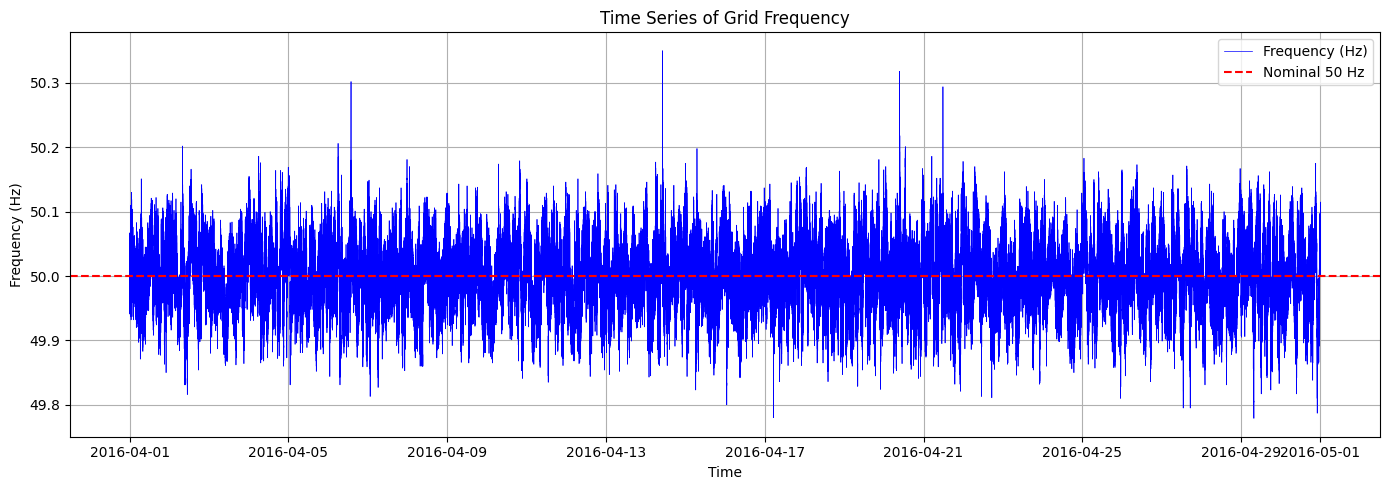

/var/folders/wk/smqrf7z97xvg0rhv6cm0hsn00000gn/T/ipykernel_24872/3324601353.py:25: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout(); plt.show()


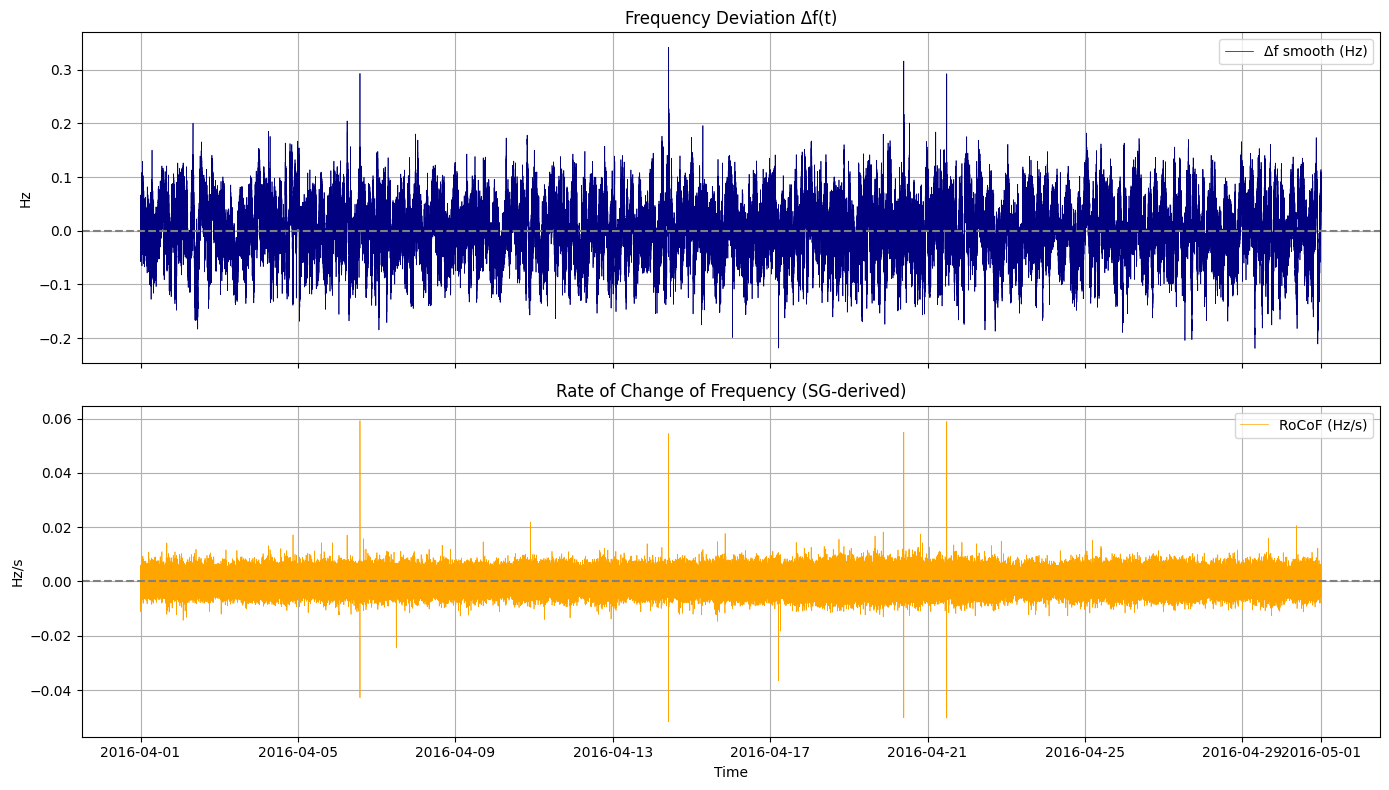

Summary statistics – frequency deviation (Hz):
count    2.591528e+07
mean     2.204511e-04
std      4.891498e-02
min     -2.210000e-01
0.1%    -1.510000e-01
1%      -1.130000e-01
5%      -8.000000e-02
25%     -3.400000e-02
50%      0.000000e+00
75%      3.400000e-02
95%      8.000000e-02
99%      1.110000e-01
99.9%    1.500000e-01
max      3.500000e-01
Name: delta_f_Hz, dtype: float64

Skewness: -0.0131  | Kurtosis: -0.0989

Share of time outside deviation bands (reliable samples only):
  |Δf| > 0.01 Hz: 83.7124%  (~21,694,303 samples)
  |Δf| > 0.02 Hz: 68.6324%  (~17,786,267 samples)
  |Δf| > 0.05 Hz: 31.0319%  (~8,042,014 samples)
  |Δf| > 0.10 Hz: 3.5987%  (~932,614 samples)
  |Δf| > 0.20 Hz: 0.0057%  (~1,481 samples)


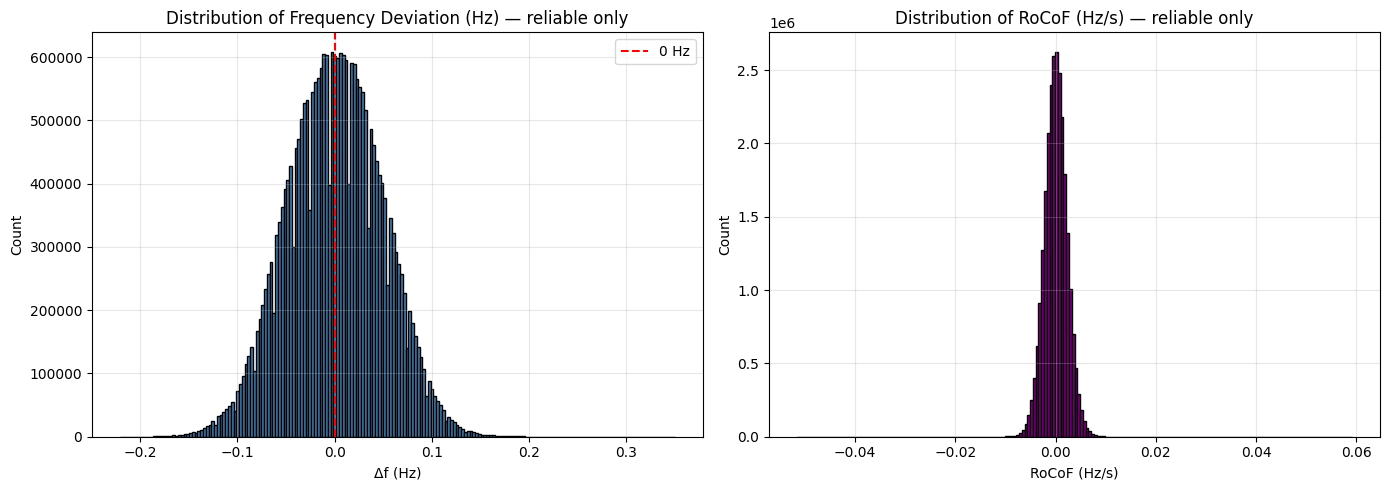

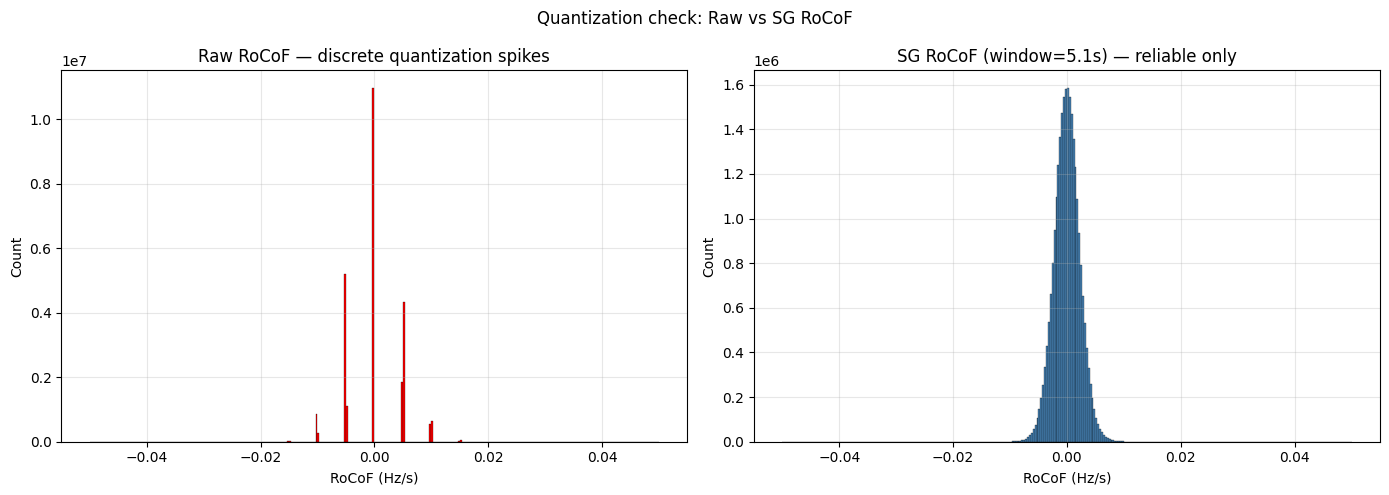

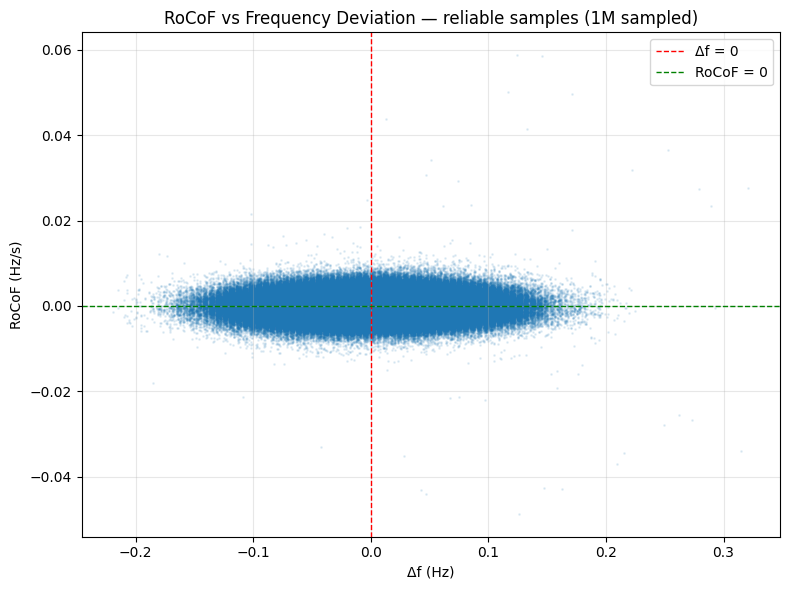

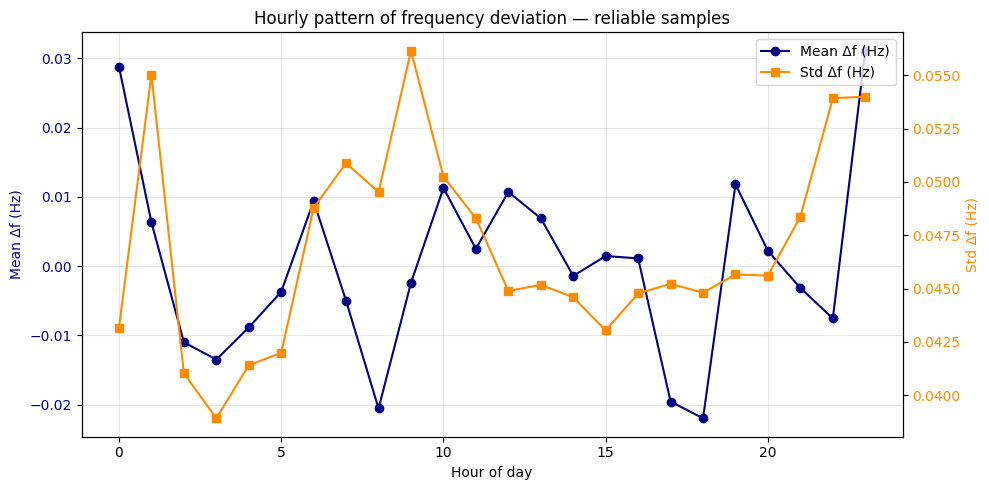

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 4 — EDA PLOTS
# ═══════════════════════════════════════════════════════════════════════════════

# ── 4a: Frequency time series ─────────────────────────────────────────────────
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['frequency'], color='blue', linewidth=0.5, label='Frequency (Hz)')
plt.axhline(50, color='red', linestyle='--', label='Nominal 50 Hz')
plt.title("Time Series of Grid Frequency")
plt.xlabel("Time"); plt.ylabel("Frequency (Hz)")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# ── 4b: Δf and RoCoF time series (full month) ─────────────────────────────────
fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axs[0].plot(df.index, df['delta_f_smooth'], color='navy', linewidth=0.5, label='Δf smooth (Hz)')
axs[0].axhline(0, linestyle='--', color='gray')
axs[0].set_title('Frequency Deviation Δf(t)')
axs[0].set_ylabel('Hz'); axs[0].grid(True); axs[0].legend()

axs[1].plot(df.index, df['rocof_Hz_per_s'], color='orange', linewidth=0.5, label='RoCoF (Hz/s)')
axs[1].axhline(0, linestyle='--', color='gray')
axs[1].set_title('Rate of Change of Frequency (SG-derived)')
axs[1].set_ylabel('Hz/s'); axs[1].set_xlabel('Time')
axs[1].grid(True); axs[1].legend()
plt.tight_layout(); plt.show()

# ── 4c: Summary statistics ────────────────────────────────────────────────────
pcts = [0.001, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999]
print("Summary statistics – frequency deviation (Hz):")
print(df_reliable['delta_f_Hz'].describe(percentiles=pcts))
print("\nSkewness:", round(df_reliable['delta_f_Hz'].skew(), 4),
      " | Kurtosis:", round(df_reliable['delta_f_Hz'].kurt(), 4))

bands_Hz = [0.01, 0.02, 0.05, 0.10, 0.20]
N_rel = len(df_reliable)
print("\nShare of time outside deviation bands (reliable samples only):")
for band in bands_Hz:
    frac = (df_reliable['delta_f_Hz'].abs() > band).mean()
    print(f"  |Δf| > {band:.2f} Hz: {frac*100:6.4f}%  (~{int(frac*N_rel):,} samples)")

# ── 4d: Distributions ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df_reliable['delta_f_Hz'].dropna(), bins=200,
             color='steelblue', edgecolor='black')
axes[0].axvline(0, color='red', linestyle='--', label='0 Hz')
axes[0].set_title('Distribution of Frequency Deviation (Hz) — reliable only')
axes[0].set_xlabel('Δf (Hz)'); axes[0].set_ylabel('Count')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].hist(df_reliable['rocof_Hz_per_s'].dropna(), bins=200,
             color='purple', edgecolor='black')
axes[1].set_title('Distribution of RoCoF (Hz/s) — reliable only')
axes[1].set_xlabel('RoCoF (Hz/s)'); axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# ── 4e: Quantization check — raw diff vs SG ───────────────────────────────────
# arr is the fully interpolated array used as SG input (major gaps bridged)
# This is intentional here — we want to show raw quantization before any masking
rocof_raw = np.gradient(arr, DT)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
clip = 0.05
axes[0].hist(np.clip(rocof_raw, -clip, clip), bins=300,
             color='red', edgecolor='black', linewidth=0.2)
axes[0].set_title('Raw RoCoF — discrete quantization spikes')
axes[0].set_xlabel('RoCoF (Hz/s)'); axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3)

axes[1].hist(np.clip(df_reliable['rocof_Hz_per_s'].dropna().values, -clip, clip),
             bins=300, color='steelblue', edgecolor='black', linewidth=0.2)
axes[1].set_title(f'SG RoCoF (window={wlen*DT:.1f}s) — reliable only')
axes[1].set_xlabel('RoCoF (Hz/s)'); axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3)
plt.suptitle('Quantization check: Raw vs SG RoCoF', fontsize=12)
plt.tight_layout(); plt.show()

# ── 4f: RoCoF vs Δf scatter (sampled from reliable data) ──────────────────────
max_pts = 1_000_000
scatter_sample = (df_reliable.sample(n=max_pts, random_state=1)
                  if len(df_reliable) > max_pts else df_reliable)
plt.figure(figsize=(8, 6))
plt.scatter(scatter_sample['delta_f_Hz'], scatter_sample['rocof_Hz_per_s'],
            s=1, alpha=0.1)
plt.axvline(0, color='red',   linestyle='--', linewidth=1, label='Δf = 0')
plt.axhline(0, color='green', linestyle='--', linewidth=1, label='RoCoF = 0')
plt.xlabel('Δf (Hz)'); plt.ylabel('RoCoF (Hz/s)')
plt.title('RoCoF vs Frequency Deviation — reliable samples (1M sampled)')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# ── 4g: Hourly pattern (reliable data only) ───────────────────────────────────
max_pts_hourly = 1_000_000
sample_hourly  = (df_reliable.sample(n=max_pts_hourly, random_state=0).sort_index()
                  if len(df_reliable) > max_pts_hourly else df_reliable.copy())
sample_hourly['hour'] = sample_hourly.index.hour
hourly_stats = sample_hourly.groupby('hour')['delta_f_Hz'].agg(['mean', 'std'])

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(hourly_stats.index, hourly_stats['mean'], marker='o',
         color='navy', label='Mean Δf (Hz)')
ax1.set_xlabel('Hour of day')
ax1.set_ylabel('Mean Δf (Hz)', color='navy')
ax1.tick_params(axis='y', labelcolor='navy')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(hourly_stats.index, hourly_stats['std'], marker='s',
         color='darkorange', label='Std Δf (Hz)')
ax2.set_ylabel('Std Δf (Hz)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.title('Hourly pattern of frequency deviation — reliable samples')
fig.tight_layout(); plt.show()

In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 6 — DISTURBANCE EVENT DETECTION
# All thresholds grounded in Nordic reserve framework (Table I)
# ═══════════════════════════════════════════════════════════════════════════════

# ── 6a: Thresholds from Nordic reserve framework ──────────────────────────────
FREQ_THRESH      = 0.2    # Hz — FCR-D activation boundary (49.9/50.1 Hz)
MIN_DURATION_S   = 5.0    # s  — FCR-D Full Activation Time (FAT)
MIN_EVENT_GAP_S  = 1200   # s  — FCR-D minimum endurance (20 min)
PRE_SEARCH_S     = 30     # s  — look back before crossing for true onset
POST_WINDOW_S    = 300    # s  — look forward for peak and recovery detection
ROCOF_LAG_MAX_S  = 10     # s  — peak RoCoF must occur within this of onset
MAX_RECOVERY_S   = 60     # s  — max time from peak to 50%/80% recovery
                           #      longer → FCR-N/aFRR dominated, exclude

# RoCoF onset threshold: data-derived (Nσ of reliable RoCoF)
rocof_std        = float(df_reliable['rocof_Hz_per_s'].std())
SIGMA_LEVELS     = [2, 3, 4]
ROCOF_THRESHOLDS = {s: round(s * rocof_std, 6) for s in SIGMA_LEVELS}

print("═" * 60)
print("THRESHOLDS — grounded in Nordic reserve framework (Table I)")
print("═" * 60)
print(f"FREQ_THRESH      : {FREQ_THRESH} Hz       (FCR-D activation boundary)")
print(f"MIN_DURATION_S   : {MIN_DURATION_S} s         (FCR-D Full Activation Time)")
print(f"MIN_EVENT_GAP_S  : {MIN_EVENT_GAP_S} s       (FCR-D minimum endurance = 20 min)")
print(f"MAX_RECOVERY_S   : {MAX_RECOVERY_S} s        (max time-to-recovery, beyond = FCR dominated)")
print(f"PRE_SEARCH_S     : {PRE_SEARCH_S} s        (onset trace-back window)")
print(f"POST_WINDOW_S    : {POST_WINDOW_S} s       (detection look-forward window)")
print(f"RoCoF σ          : {rocof_std:.6f} Hz/s")
for s, v in ROCOF_THRESHOLDS.items():
    print(f"  {s}σ onset thresh: {v:.6f} Hz/s")
print("═" * 60)

# ── 6b: Event detection function ─────────────────────────────────────────────
def detect_events(df_rel, freq_thresh, rocof_onset_thresh,
                  min_gap_s, min_duration_s, pre_search_s,
                  post_window_s, rocof_lag_max_s, max_recovery_s):

    # Raw threshold crossings (rising edges only)
    outside       = df_rel['delta_f_Hz'].abs() > freq_thresh
    state_change  = outside & ~outside.shift(fill_value=False)
    raw_crossings = df_rel[state_change].index.tolist()
    if len(raw_crossings) == 0:
        return pd.DataFrame(), 0

    # Merge crossings within min_gap_s (same physical event)
    merged = [raw_crossings[0]]
    for t in raw_crossings[1:]:
        if (t - merged[-1]).total_seconds() > min_gap_s:
            merged.append(t)

    seg_records = []
    for t in merged:
        pre_start = t - pd.Timedelta(seconds=pre_search_s)
        post_end  = t + pd.Timedelta(seconds=post_window_s)
        window    = df_rel.loc[pre_start:post_end]
        if len(window) < 10:
            continue

        # Minimum duration filter: crossing must persist for MIN_DURATION_S
        crossing_window = df_rel.loc[t : t + pd.Timedelta(seconds=min_duration_s)]
        if not (crossing_window['delta_f_Hz'].abs() > freq_thresh).all():
            continue

        # True onset: trace back to first RoCoF exceeding onset threshold
        pre_window  = df_rel.loc[pre_start:t]
        rocof_above = pre_window['rocof_Hz_per_s'].abs() > rocof_onset_thresh
        onset_time  = pre_window[rocof_above].index[0] if rocof_above.any() else t

        # Peak Δf after onset
        post_onset = window.loc[onset_time:]
        if len(post_onset) == 0:
            continue
        peak_idx  = post_onset['delta_f_Hz'].abs().idxmax()
        peak_df   = float(post_onset.loc[peak_idx, 'delta_f_Hz'])
        direction = 'under' if peak_df < 0 else 'over'

        # Peak RoCoF and lag from onset
        peak_rocof      = float(window['rocof_Hz_per_s'].abs().max())
        peak_rocof_time = window['rocof_Hz_per_s'].abs().idxmax()
        rocof_lag       = (peak_rocof_time - onset_time).total_seconds()

        # ── Recovery ─────────────────────────────────────────────────────
        # Four tiers based on speed and depth of recovery:
        #
        #   50%_fast — 50% recovery within MAX_RECOVERY_S of peak
        #              → clean inertial decay, ideal for H/D estimation
        #   80%_fast — 80% recovery within MAX_RECOVERY_S of peak
        #              → acceptable, slightly slower inertial response
        #   50%_slow — 50% recovery but takes longer than MAX_RECOVERY_S
        #              → FCR-N/aFRR dominated, swing eq model unreliable
        #   none     — no recovery within post-window
        #              → exclude from estimation
        #
        # Physical basis: FCR-D FAT = 5s, aFRR activates within 2-5 min.
        # Clean inertial decay should complete well within 60s of peak.
        # Beyond that, reserve activation is masking the natural response.

        peak_abs        = abs(peak_df)
        post_peak       = post_onset.loc[peak_idx:]
        recovery_window = post_peak.iloc[:int(post_window_s / DT)]
        fast_window     = post_peak.iloc[:int(max_recovery_s / DT)]

        recovery_50_fast = fast_window[
            fast_window['delta_f_Hz'].abs() < peak_abs * 0.5
        ]
        recovery_80_fast = fast_window[
            fast_window['delta_f_Hz'].abs() < peak_abs * 0.8
        ]
        recovery_50_slow = recovery_window[
            recovery_window['delta_f_Hz'].abs() < peak_abs * 0.5
        ]

        if len(recovery_50_fast) > 0:
            end_time      = recovery_50_fast.index[0]
            recovery_type = '50%_fast'
        elif len(recovery_80_fast) > 0:
            end_time      = recovery_80_fast.index[0]
            recovery_type = '80%_fast'
        elif len(recovery_50_slow) > 0:
            end_time      = recovery_50_slow.index[0]
            recovery_type = '50%_slow'
        else:
            end_time      = recovery_window.index[-1]
            recovery_type = 'none'

        duration = (end_time - onset_time).total_seconds()

        seg_records.append({
            'onset_time'     : onset_time,
            'peak_time'      : peak_idx,
            'peak_rocof_time': peak_rocof_time,
            'end_time'       : end_time,
            'direction'      : direction,
            'peak_df_Hz'     : round(peak_df,    4),
            'max_rocof_Hz_s' : round(peak_rocof, 5),
            'rocof_lag_s'    : round(rocof_lag,  1),
            'duration_s'     : round(duration,   1),
            'recovery_type'  : recovery_type,
        })

    segs = pd.DataFrame(seg_records).reset_index(drop=True)
    if len(segs) == 0:
        return segs, len(raw_crossings)

    # ── Classification scaled to data RoCoF distribution ─────────────────
    strong_thresh   = 8 * rocof_std
    moderate_thresh = 4 * rocof_std

    def classify(row):
        lag_ok = row['rocof_lag_s'] < rocof_lag_max_s
        if row['max_rocof_Hz_s'] > strong_thresh   and lag_ok: return 'STRONG'
        if row['max_rocof_Hz_s'] > moderate_thresh and lag_ok: return 'MODERATE'
        return 'WEAK'

    segs['classification'] = segs.apply(classify, axis=1)
    return segs, len(raw_crossings)

# ── 6c: Run for all sigma levels and compare ─────────────────────────────────
print("\nSIGMA COMPARISON")
print("═" * 60)
sigma_results = {}
for s in SIGMA_LEVELS:
    thresh = ROCOF_THRESHOLDS[s]
    segs, n_raw = detect_events(
        df_reliable, FREQ_THRESH, thresh,
        MIN_EVENT_GAP_S, MIN_DURATION_S,
        PRE_SEARCH_S, POST_WINDOW_S,
        ROCOF_LAG_MAX_S, MAX_RECOVERY_S
    )
    sigma_results[s] = segs
    if len(segs) == 0:
        print(f"\nσ = {s}: no events detected")
        continue

    n_strong     = (segs['classification'] == 'STRONG').sum()
    n_moderate   = (segs['classification'] == 'MODERATE').sum()
    n_weak       = (segs['classification'] == 'WEAK').sum()
    n_fast       = segs['recovery_type'].isin(['50%_fast', '80%_fast']).sum()
    n_slow       = (segs['recovery_type'] == '50%_slow').sum()
    n_none       = (segs['recovery_type'] == 'none').sum()
    n_est        = ((segs['classification'] != 'WEAK') &
                    (segs['recovery_type'].isin(['50%_fast', '80%_fast']))).sum()

    print(f"\nσ = {s}  (onset threshold = {thresh:.6f} Hz/s)")
    print(f"  Raw crossings          : {n_raw}")
    print(f"  After merge+filter     : {len(segs)}")
    print(f"  STRONG                 : {n_strong}")
    print(f"  MODERATE               : {n_moderate}")
    print(f"  WEAK                   : {n_weak}")
    print(f"  Recovery 50%/80% fast  : {n_fast}  ← estimation-eligible")
    print(f"  Recovery 50% slow      : {n_slow}  ← FCR dominated, excluded")
    print(f"  No recovery            : {n_none}  ← excluded")
    print(f"  Estimation-grade final : {n_est}")

# ── 6d: Pick sigma level and build final estimation table ────────────────────
SIGMA_CHOICE = 3
segments     = sigma_results[SIGMA_CHOICE].copy()

segments_est = segments[
    (segments['classification'] != 'WEAK') &
    (segments['recovery_type'].isin(['50%_fast', '80%_fast']))
].copy().reset_index(drop=True)

print(f"\n→ Using σ = {SIGMA_CHOICE} | "
      f"{len(segments_est)} estimation-grade events")
print(f"\nRecovery type breakdown:")
print(segments_est['recovery_type'].value_counts())
print(f"\nEstimation-grade events:")
display(segments_est)

════════════════════════════════════════════════════════════
THRESHOLDS — grounded in Nordic reserve framework (Table I)
════════════════════════════════════════════════════════════
FREQ_THRESH      : 0.2 Hz       (FCR-D activation boundary)
MIN_DURATION_S   : 5.0 s         (FCR-D Full Activation Time)
MIN_EVENT_GAP_S  : 1200 s       (FCR-D minimum endurance = 20 min)
MAX_RECOVERY_S   : 60 s        (max time-to-recovery, beyond = FCR dominated)
PRE_SEARCH_S     : 30 s        (onset trace-back window)
POST_WINDOW_S    : 300 s       (detection look-forward window)
RoCoF σ          : 0.002265 Hz/s
  2σ onset thresh: 0.004531 Hz/s
  3σ onset thresh: 0.006796 Hz/s
  4σ onset thresh: 0.009062 Hz/s
════════════════════════════════════════════════════════════

SIGMA COMPARISON
════════════════════════════════════════════════════════════

σ = 2  (onset threshold = 0.004531 Hz/s)
  Raw crossings          : 25
  After merge+filter     : 8
  STRONG                 : 4
  MODERATE               : 1


,onset_time,peak_time,peak_rocof_time,end_time,direction,peak_df_Hz,max_rocof_Hz_s,rocof_lag_s,duration_s,recovery_type,classification
0,2016-04-06 06:00:09.000,2016-04-06 06:00:25.500,2016-04-06 06:00:12.700,2016-04-06 06:00:37.900,over,0.206,0.01705,3.7,28.9,80%_fast,MODERATE
1,2016-04-06 13:49:54.200,2016-04-06 13:50:01.700,2016-04-06 13:49:55.900,2016-04-06 13:50:06.700,over,0.302,0.05920,1.7,12.5,50%_fast,STRONG
2,2016-04-14 10:07:06.600,2016-04-14 10:07:14.200,2016-04-14 10:07:08.500,2016-04-14 10:07:18.400,over,0.350,0.05445,1.9,11.8,50%_fast,STRONG
3,2016-04-17 05:13:21.100,2016-04-17 05:13:31.300,2016-04-17 05:13:23.100,2016-04-17 05:13:47.400,under,-0.220,0.03657,2.0,26.3,50%_fast,STRONG
4,2016-04-20 09:31:17.600,2016-04-20 09:31:25.800,2016-04-20 09:31:19.300,2016-04-20 09:31:31.200,over,0.318,0.05494,1.7,13.6,50%_fast,STRONG
5,2016-04-21 11:43:41.800,2016-04-21 11:43:50.300,2016-04-21 11:43:43.500,2016-04-21 11:43:55.900,over,0.294,0.05887,1.7,14.1,50%_fast,STRONG


In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 7 — SEGMENT INSPECTION HELPER
# ═══════════════════════════════════════════════════════════════════════════════

def plot_segment(segment_row, pre_seconds=15, post_seconds=120,
                 seg_table=None):
    if seg_table is None:
        seg_table = segments_est

    if segment_row >= len(seg_table):
        print(f"segment_row {segment_row} out of range "
              f"(table has {len(seg_table)} rows)")
        return

    seg          = seg_table.iloc[segment_row]
    onset        = seg['onset_time']
    peak         = seg['peak_time']
    end          = seg['end_time']
    peak_rocof_t = seg['peak_rocof_time']
    label        = seg.get('classification', '')
    direction    = seg.get('direction', '')
    recovery     = seg.get('recovery_type', '')

    window = df_reliable.loc[
        onset - pd.Timedelta(seconds=pre_seconds):
        onset + pd.Timedelta(seconds=post_seconds)
    ]

    if len(window) == 0:
        print(f"No data in window for segment {segment_row}")
        return

    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

    # ── Δf panel ──────────────────────────────────────────────────────────
    axes[0].plot(window.index, window['delta_f_Hz'],
                 color='navy', linewidth=0.8, label='Δf (Hz)')
    axes[0].axhline(0,            linestyle='--', color='gray', linewidth=0.8)
    axes[0].axhline(+FREQ_THRESH, linestyle=':', color='red',
                    linewidth=1, label=f'+{FREQ_THRESH:.2f} Hz (FCR-D)')
    axes[0].axhline(-FREQ_THRESH, linestyle=':', color='red',
                    linewidth=1, label=f'-{FREQ_THRESH:.2f} Hz (FCR-D)')
    axes[0].axvline(onset, color='red',    linestyle='--',
                    linewidth=1.2, label='Onset')
    axes[0].axvline(peak,  color='purple', linestyle='--',
                    linewidth=1.2, label=f'Peak Δf ({seg["peak_df_Hz"]:+.4f} Hz)')
    axes[0].axvline(end,   color='green',  linestyle='--',
                    linewidth=1.2, label=f'Recovery ({recovery})')
    axes[0].set_ylabel('Δf (Hz)')
    axes[0].set_title(
        f'Event #{segment_row}  [{label}]  {direction}  |  '
        f'onset: {onset}  |  '
        f'duration: {seg["duration_s"]:.1f} s  |  '
        f'recovery: {recovery}'
    )
    axes[0].legend(fontsize=8, loc='upper right')
    axes[0].grid(True, alpha=0.3)

    # ── RoCoF panel ───────────────────────────────────────────────────────
    rocof_thresh_used = ROCOF_THRESHOLDS[SIGMA_CHOICE]
    axes[1].plot(window.index, window['rocof_Hz_per_s'],
                 color='darkorange', linewidth=0.8, label='RoCoF (Hz/s)')
    axes[1].axhline(0,                   linestyle='--', color='gray',
                    linewidth=0.8)
    axes[1].axhline(+rocof_thresh_used,  linestyle=':', color='purple',
                    linewidth=1, label=f'+{SIGMA_CHOICE}σ onset threshold')
    axes[1].axhline(-rocof_thresh_used,  linestyle=':', color='purple',
                    linewidth=1, label=f'-{SIGMA_CHOICE}σ onset threshold')
    axes[1].axvline(onset,        color='red',    linestyle='--', linewidth=1.2)
    axes[1].axvline(peak_rocof_t, color='blue',   linestyle='--',
                    linewidth=1.2,
                    label=f'Peak RoCoF ({seg["max_rocof_Hz_s"]:.5f} Hz/s, '
                          f'lag={seg["rocof_lag_s"]:.1f}s)')
    axes[1].axvline(peak,  color='purple', linestyle='--', linewidth=1.2)
    axes[1].axvline(end,   color='green',  linestyle='--', linewidth=1.2)
    axes[1].set_ylabel('RoCoF (Hz/s)')
    axes[1].set_xlabel('Time')
    axes[1].legend(fontsize=8, loc='upper right')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ── Plot all estimation-grade events ─────────────────────────────────────────
for i in range(len(segments_est)):
    seg_i = segments_est.iloc[i]
    print(f"\n{'─'*60}")
    print(f"Event {i:>2}  |  {seg_i['classification']:<8}  |  "
          f"{seg_i['direction']:<5}  |  "
          f"{seg_i['onset_time']}  |  "
          f"peak Δf = {seg_i['peak_df_Hz']:+.4f} Hz  |  "
          f"max RoCoF = {seg_i['max_rocof_Hz_s']:.5f} Hz/s  |  "
          f"recovery = {seg_i['recovery_type']}")
    #plot_segment(i)


────────────────────────────────────────────────────────────
Event  0  |  MODERATE  |  over   |  2016-04-06 06:00:09  |  peak Δf = +0.2060 Hz  |  max RoCoF = 0.01705 Hz/s  |  recovery = 80%_fast

────────────────────────────────────────────────────────────
Event  1  |  STRONG    |  over   |  2016-04-06 13:49:54.200000  |  peak Δf = +0.3020 Hz  |  max RoCoF = 0.05920 Hz/s  |  recovery = 50%_fast

────────────────────────────────────────────────────────────
Event  2  |  STRONG    |  over   |  2016-04-14 10:07:06.600000  |  peak Δf = +0.3500 Hz  |  max RoCoF = 0.05445 Hz/s  |  recovery = 50%_fast

────────────────────────────────────────────────────────────
Event  3  |  STRONG    |  under  |  2016-04-17 05:13:21.100000  |  peak Δf = -0.2200 Hz  |  max RoCoF = 0.03657 Hz/s  |  recovery = 50%_fast

────────────────────────────────────────────────────────────
Event  4  |  STRONG    |  over   |  2016-04-20 09:31:17.600000  |  peak Δf = +0.3180 Hz  |  max RoCoF = 0.05494 Hz/s  |  recovery = 5

In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 8 — DECAY FIT: ESTIMATE α PER EVENT
#
# Physics: after a disturbance, if ΔP decays and reserves haven't fully
# activated, Δf(t) ≈ A·exp(-αt) where α = D/(2H)
# We fit log(|Δf|) vs t in the decay window (peak → recovery) to get α.
# Quality gate: R² ≥ MIN_R2 — only well-fitted decays proceed to H/D step.
# ═══════════════════════════════════════════════════════════════════════════════

from scipy.stats import linregress

MIN_R2           = 0.70   # minimum R² for decay fit to be usable
NOISE_FLOOR_HZ   = 0.002  # Hz — ignore samples below this (quantization noise)
DECAY_OFFSET_S   = 0.5    # s  — skip this many seconds after peak before fitting
                           #      avoids the peak itself distorting the log fit

def fit_decay_alpha(df_rel, seg, noise_floor=NOISE_FLOOR_HZ,
                    offset_s=DECAY_OFFSET_S):
    """
    Fit exponential decay Δf(t) ≈ A·exp(-αt) in the window
    from peak+offset_s to end_time.
    Returns dict with alpha, r2, fit metadata or None if unusable.
    """
    peak    = seg['peak_time']
    end     = seg['end_time']

    decay_start = peak + pd.Timedelta(seconds=offset_s)
    decay_end   = end

    df_decay = df_rel.loc[decay_start:decay_end].copy()
    if len(df_decay) < 20:
        return None

    df_decay['t_sec']    = (df_decay.index - decay_start).total_seconds()
    df_decay['abs_df']   = df_decay['delta_f_Hz'].abs()

    # Remove noise floor
    df_fit = df_decay[df_decay['abs_df'] > noise_floor].copy()
    if len(df_fit) < 20:
        return None

    df_fit['log_abs_df'] = np.log(df_fit['abs_df'])

    res   = linregress(df_fit['t_sec'], df_fit['log_abs_df'])
    alpha = -res.slope
    r2    = res.rvalue ** 2

    return {
        'alpha'      : alpha,
        'r2'         : r2,
        'intercept'  : res.intercept,
        'n_samples'  : len(df_fit),
        'decay_start': decay_start,
        'decay_end'  : decay_end,
    }


# ── Run decay fit for all estimation-grade events ────────────────────────────
decay_results = []
for i, seg in segments_est.iterrows():
    out = fit_decay_alpha(df_reliable, seg)
    if out is None:
        continue
    out['segment_idx'] = i
    decay_results.append(out)

decay_df = pd.DataFrame(decay_results)
print(f"Decay fit converged : {len(decay_df)} / {len(segments_est)} events")
print(f"\nAlpha summary (1/s):")
print(decay_df['alpha'].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]))
print(f"\nR² summary:")
print(decay_df['r2'].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]))

# Quality gate
decay_good = decay_df[decay_df['r2'] >= MIN_R2].copy()
print(f"\nAfter R² ≥ {MIN_R2} filter: {len(decay_good)} events")

Decay fit converged : 6 / 6 events

Alpha summary (1/s):
count    6.000000
mean     0.108339
std      0.059789
min      0.019484
5%       0.026555
25%      0.069382
50%      0.135965
75%      0.141175
95%      0.161971
max      0.168518
Name: alpha, dtype: float64

R² summary:
count    6.000000
mean     0.968014
std      0.014050
min      0.951637
5%       0.952788
25%      0.957092
50%      0.968115
75%      0.977032
95%      0.984390
max      0.986793
Name: r2, dtype: float64

After R² ≥ 0.7 filter: 6 events


In [9]:
# # ═══════════════════════════════════════════════════════════════════════════════
# # SECTION 9 — H AND D ESTIMATION FROM SWING EQUATION WITH KNOWN ΔP AND Ek
# #
# # METHOD:
# #   2H·dΔf/dt + D·Δf = ΔP_pu   (swing equation, all pu)
# #
# #   ΔP [MW] and Ek [GWs] known per event from TSO disturbance report.
# #   H and D derived directly — no optimisation ambiguity, identifiability resolved.
# #
# #   H:
# #     H_from_Ek    = Ek_GWs × 1000 / S_base_MW                     [primary]
# #     H_from_RoCoF = (ΔP_pu - D·Δf_pre_pu) / (2 × |RoCoF_0_pu|)   [cross-check]
# #     RoCoF_0 from linear regression over onset→nadir (mean inertial slope).
# #
# #   D — two physically distinct quantities:
# #
# #     D_from_ss [effective damping]:
# #       D = ΔP_pu / |Δf_ss_pu|   where Δf_ss = mean(Δf) over 90–150s
# #       Represents combined effect of load damping + FCR-D reserve response.
# #       Useful for steady-state frequency deviation analysis.
# #       NOT the pure swing equation D — FCR-D has already acted by 90s.
# #
# #     D_inertial [true swing equation D]:
# #       Single-parameter fit of swing equation to onset→nadir data,
# #       with H fixed from Ek and ΔP fixed from report table.
# #       Only D is free → well-posed, identifiable single-parameter problem.
# #       Reflects pure load damping during the ~7s inertial phase
# #       before FCR-D has meaningfully activated.
# #
# #   Validation (S_base-free):
# #     α_table = ΔP·f0 / (2·Ek·1000·|Δf_ss|)
# #     α_model = D_from_ss / (2·H_Ek)      → equals α_table by construction
# #     α_inertial = D_inertial / (2·H_Ek)  → independent estimate from inertial fit
# #
# # ═══════════════════════════════════════════════════════════════════════════════

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from scipy.stats import linregress
# from scipy.optimize import minimize_scalar

# # ── Constants ─────────────────────────────────────────────────────────────────
# S_BASE_MW   = 45000.0  # MW — Nordic synchronous load, April 2016 (stated assumption)
# F0          = 50.0     # Hz
# PRE_ONSET_S = 30.0     # s — pre-onset window for Δf_pre
# SS_WIN_LO_S = 90.0     # s — steady-state window start (ENTSO-E convention)
# SS_WIN_HI_S = 150.0    # s — steady-state window end

# # D_inertial fit bounds [pu] — physically plausible load damping range
# D_INERTIAL_LO = 0.05
# D_INERTIAL_HI = 5.0

# print("═" * 65)
# print("SECTION 9 — H AND D ESTIMATION WITH KNOWN ΔP AND Ek")
# print("═" * 65)
# print(f"S_base (stated assumption) : {S_BASE_MW:.0f} MW")
# print(f"f0                         : {F0:.1f} Hz")
# print(f"RoCoF_0 method             : linear regression over onset→nadir")
# print(f"D_from_ss                  : effective damping (ΔP/Δf_ss, 90–150s)")
# print(f"D_inertial                 : true swing D — single-param fit, H and ΔP fixed")


# # ── Report disturbance table — 2016 ──────────────────────────────────────────
# report_events = pd.DataFrame([
#     {"date_str": "2016-01-12 10:22:53", "delta_f_Hz": -0.335, "delta_P_MW": 1167, "delta_t_s":  9.0, "Ek_GWs": 274, "cause": "Nuclear"},
#     {"date_str": "2016-02-09 22:05:28", "delta_f_Hz":  0.214, "delta_P_MW":  880, "delta_t_s":  8.3, "Ek_GWs": 252, "cause": "HVDC"},
#     {"date_str": "2016-02-20 10:45:31", "delta_f_Hz": -0.348, "delta_P_MW": 1000, "delta_t_s": 10.7, "Ek_GWs": 227, "cause": "Nuclear"},
#     {"date_str": "2016-02-24 12:30:29", "delta_f_Hz":  0.228, "delta_P_MW":  700, "delta_t_s":  9.0, "Ek_GWs": 251, "cause": "HVDC"},
#     {"date_str": "2016-03-21 11:59:50", "delta_f_Hz":  0.269, "delta_P_MW":  723, "delta_t_s":  7.3, "Ek_GWs": 248, "cause": "HVDC"},
#     {"date_str": "2016-04-06 13:49:55", "delta_f_Hz":  0.230, "delta_P_MW":  700, "delta_t_s":  6.7, "Ek_GWs": 221, "cause": "HVDC"},
#     {"date_str": "2016-04-14 10:07:07", "delta_f_Hz":  0.234, "delta_P_MW":  700, "delta_t_s":  6.7, "Ek_GWs": 240, "cause": "HVDC"},
#     {"date_str": "2016-04-20 09:31:18", "delta_f_Hz":  0.249, "delta_P_MW":  700, "delta_t_s":  7.1, "Ek_GWs": 224, "cause": "HVDC"},
#     {"date_str": "2016-04-21 11:43:42", "delta_f_Hz":  0.283, "delta_P_MW":  700, "delta_t_s":  7.9, "Ek_GWs": 222, "cause": "HVDC"},
# ])
# report_events['report_time'] = pd.to_datetime(report_events['date_str'])
# report_events['direction']   = report_events['delta_f_Hz'].apply(
#     lambda x: 'over' if x > 0 else 'under')


# # ── Cross-match: report event → detected segment ──────────────────────────────
# MATCH_TOL_S = 120

# def match_report_to_segment(rrow, segs, tol=MATCH_TOL_S):
#     r_time = rrow['report_time']
#     t_lo   = r_time - pd.Timedelta(seconds=rrow['delta_t_s'] + tol)
#     t_hi   = r_time + pd.Timedelta(seconds=30)
#     cands  = segs[
#         (segs['onset_time'] >= t_lo) &
#         (segs['onset_time'] <= t_hi) &
#         (segs['direction']  == rrow['direction'])
#     ].copy()
#     if cands.empty:
#         return None, None
#     expected    = r_time - pd.Timedelta(seconds=rrow['delta_t_s'])
#     cands['dt'] = (cands['onset_time'] - expected).abs()
#     best        = cands.nsmallest(1, 'dt')
#     return best.index[0], best.iloc[0]

# print("\n" + "─" * 65)
# print("CROSS-MATCHING REPORT EVENTS → DETECTED SEGMENTS")
# print("─" * 65)

# matched_rows = []
# for _, rrow in report_events.iterrows():
#     seg_idx, seg = match_report_to_segment(rrow, segments_est)
#     print(f"  {rrow['date_str']}  "
#           f"{'✓ MATCHED' if seg_idx is not None else '✗ NO MATCH':12s}"
#           f"  onset={str(seg['onset_time']) if seg_idx is not None else '—'}")
#     if seg_idx is not None:
#         matched_rows.append({**rrow.to_dict(),
#                               'seg_idx'       : seg_idx,
#                               'onset_time'    : seg['onset_time'],
#                               'peak_df_Hz'    : seg['peak_df_Hz'],
#                               'max_rocof_Hz_s': seg['max_rocof_Hz_s'],
#                               'classification': seg['classification'],
#                               'recovery_type' : seg['recovery_type'],
#                               'peak_time'     : seg['peak_time']})

# matched_df = pd.DataFrame(matched_rows)
# print(f"\nMatched: {len(matched_df)} / {len(report_events)}")


# # ── Swing equation analytical solution ───────────────────────────────────────
# def swing_solution(t, H, D, dP_pu, df_pre_pu):
#     """
#     Δf_pu(t) = Δf_ss + (Δf_pre - Δf_ss) · exp(-αt)
#     α = D/(2H),  Δf_ss = dP_pu/D
#     Valid during inertial phase (constant ΔP, before FCR-D acts).
#     """
#     alpha  = D / (2.0 * H)
#     df_ss  = dP_pu / D
#     return df_ss + (df_pre_pu - df_ss) * np.exp(-alpha * t)


# # ═══════════════════════════════════════════════════════════════════════════════
# # MAIN ESTIMATION LOOP
# # ═══════════════════════════════════════════════════════════════════════════════
# results = []

# print("\n" + "═" * 65)
# print("H AND D ESTIMATION — PER EVENT")
# print("═" * 65)

# for _, mrow in matched_df.iterrows():
#     seg_idx   = mrow['seg_idx']
#     seg       = segments_est.loc[seg_idx]
#     onset     = seg['onset_time']
#     nadir_t   = mrow['peak_time']
#     sign      = 1 if mrow['direction'] == 'over' else -1

#     dP_MW  = mrow['delta_P_MW']
#     Ek_GWs = mrow['Ek_GWs']
#     dP_pu  = dP_MW / S_BASE_MW

#     # ── Data windows ──────────────────────────────────────────────────────
#     pre_win      = df_reliable.loc[
#         onset - pd.Timedelta(seconds=PRE_ONSET_S) : onset]
#     ss_win       = df_reliable.loc[
#         onset + pd.Timedelta(seconds=SS_WIN_LO_S) :
#         onset + pd.Timedelta(seconds=SS_WIN_HI_S)]
#     inertial_win = df_reliable.loc[onset : nadir_t]

#     if len(pre_win) < 5 or len(ss_win) < 5 or len(inertial_win) < 5:
#         print(f"\n  Event {seg_idx}: insufficient data — skip")
#         continue

#     # ── Δf_pre ────────────────────────────────────────────────────────────
#     df_pre_Hz = float(pre_win['delta_f_Hz'].median())
#     df_pre_pu = df_pre_Hz / F0

#     # ── Δf_ss: mean of 90–150s window ────────────────────────────────────
#     df_ss_Hz  = float(ss_win['delta_f_Hz'].mean())
#     df_ss_pu  = df_ss_Hz / F0

#     # ── RoCoF_0: linear regression over inertial phase ───────────────────
#     t_vals  = (inertial_win.index - onset).total_seconds().values
#     df_vals = inertial_win['delta_f_Hz'].values
#     rocof_slope, rocof_intercept, rocof_r, *_ = linregress(t_vals, df_vals)
#     rocof_0_Hz_s = rocof_slope
#     rocof_0_pu_s = rocof_0_Hz_s / F0

#     # ── H estimates ───────────────────────────────────────────────────────
#     H_from_Ek = Ek_GWs * 1000.0 / S_BASE_MW   # primary

#     # ── D_from_ss: effective damping (post-FCR-D steady state) ───────────
#     D_from_ss = (dP_pu / abs(df_ss_pu) if abs(df_ss_pu) > 1e-4 else np.nan)

#     # ── H_from_RoCoF: cross-check with Δf_pre correction ─────────────────
#     # At t=0+: 2H·RoCoF_0 = ΔP_pu - D·Δf_pre_pu  (exact, no approximation)
#     # Use D_from_ss for the correction term (best available D estimate at this point)
#     if abs(rocof_0_pu_s) > 1e-6 and not np.isnan(D_from_ss):
#         dP_eff_pu    = dP_pu - D_from_ss * abs(df_pre_pu)
#         H_from_rocof = dP_eff_pu / (2.0 * abs(rocof_0_pu_s))
#     else:
#         dP_eff_pu    = np.nan
#         H_from_rocof = np.nan

#     H_est = H_from_Ek   # primary throughout

#     # ── D_inertial: single-parameter fit, H and ΔP fixed ─────────────────
#     # Fits swing equation to onset→nadir Δf_pu data.
#     # Only D is free — H=H_from_Ek, ΔP=from table.
#     # Well-posed: one equation, one unknown at each time step.
#     t_fit    = t_vals.copy()
#     df_fit_pu = df_vals / F0   # convert to pu for swing equation

#     dP_signed_pu = dP_pu * sign

#     def cost_D(D_try):
#         if D_try <= 0:
#             return 1e12
#         df_pred = swing_solution(t_fit, H_est, D_try, dP_signed_pu, df_pre_pu)
#         return np.sum((df_fit_pu - df_pred) ** 2)

#     opt = minimize_scalar(cost_D,
#                           bounds=(D_INERTIAL_LO, D_INERTIAL_HI),
#                           method='bounded',
#                           options={'xatol': 1e-8})
#     D_inertial = opt.x if opt.success else np.nan

#     # R² of the inertial fit
#     if not np.isnan(D_inertial):
#         df_pred_pu  = swing_solution(t_fit, H_est, D_inertial,
#                                      dP_signed_pu, df_pre_pu)
#         ss_res      = np.sum((df_fit_pu - df_pred_pu)**2)
#         ss_tot      = np.sum((df_fit_pu - df_fit_pu.mean())**2)
#         r2_inertial = 1.0 - ss_res/ss_tot if ss_tot > 1e-12 else np.nan
#         rmse_inertial_mHz = np.sqrt(np.mean(((df_fit_pu - df_pred_pu)*F0*1000)**2))
#     else:
#         r2_inertial = np.nan
#         rmse_inertial_mHz = np.nan

#     # ── α values ─────────────────────────────────────────────────────────
#     alpha_model    = D_from_ss    / (2.0 * H_est) if not np.isnan(D_from_ss)    else np.nan
#     alpha_inertial = D_inertial   / (2.0 * H_est) if not np.isnan(D_inertial)   else np.nan
#     alpha_table    = (dP_MW * F0 / (2.0 * Ek_GWs * 1000.0 * abs(df_ss_Hz))
#                       if abs(df_ss_Hz) > 1e-4 else np.nan)

#     # Section 8 decay α (FCR-D timescale, for reference only)
#     decay_row   = decay_good[decay_good['segment_idx'] == seg_idx]
#     alpha_decay = float(decay_row['alpha'].iloc[0]) if not decay_row.empty else np.nan

#     # ── RoCoF validation ──────────────────────────────────────────────────
#     rocof_pred_raw = dP_MW * F0 / (2.0 * Ek_GWs * 1000.0)
#     dP_eff_MW      = (dP_eff_pu * S_BASE_MW if not np.isnan(dP_eff_pu) else np.nan)
#     rocof_pred_eff = (dP_eff_MW * F0 / (2.0 * Ek_GWs * 1000.0)
#                       if not np.isnan(dP_eff_MW) else np.nan)
#     rocof_ratio_raw = abs(rocof_0_Hz_s) / rocof_pred_raw
#     rocof_ratio_eff = (abs(rocof_0_Hz_s) / rocof_pred_eff
#                        if (rocof_pred_eff is not None and
#                            not np.isnan(rocof_pred_eff) and
#                            rocof_pred_eff > 0) else np.nan)

#     t_nadir_s = (nadir_t - onset).total_seconds()

#     print(f"\n{'─'*65}")
#     print(f"Event {seg_idx} | {mrow['classification']} | "
#           f"{mrow['direction'].upper()} | cause={mrow['cause']}")
#     print(f"  onset={onset}   nadir Δt={t_nadir_s:.1f}s")
#     print(f"  [TABLE] ΔP={dP_MW:.0f} MW  Ek={Ek_GWs:.0f} GWs  "
#           f"Δf_nadir={mrow['delta_f_Hz']:.3f} Hz")
#     print(f"  [DATA]  Δf_pre={df_pre_Hz:.4f} Hz  Δf_ss={df_ss_Hz:.4f} Hz  "
#           f"RoCoF_0={rocof_0_Hz_s:.5f} Hz/s  (linreg R²={rocof_r**2:.3f})")
#     print(f"  ── H ──────────────────────────────────────────────────")
#     print(f"    H_from_Ek         = {H_from_Ek:.3f} s   [primary]")
#     print(f"    H_from_RoCoF      = {H_from_rocof:.3f} s   [cross-check, Δf_pre-corrected]")
#     print(f"    Ratio H_RoCoF/H_Ek = {H_from_rocof/H_from_Ek:.3f}")
#     print(f"  ── D ──────────────────────────────────────────────────")
#     print(f"    D_from_ss         = {D_from_ss:.4f} pu  [effective: load damping + FCR-D]")
#     print(f"    D_inertial        = {D_inertial:.4f} pu  [true swing D: inertial phase fit]")
#     print(f"    α_model           = {alpha_model:.5f} 1/s  (D_ss/2H_Ek = α_table by construction)")
#     print(f"    α_inertial        = {alpha_inertial:.5f} 1/s  (D_inertial/2H_Ek)")
#     print(f"    D_inertial fit R² = {r2_inertial:.4f}  RMSE={rmse_inertial_mHz:.2f} mHz")
#     print(f"  ── Validation (S_base-free) ───────────────────────────")
#     print(f"    RoCoF_pred raw    = {rocof_pred_raw:.5f} Hz/s")
#     print(f"    RoCoF_pred eff    = {rocof_pred_eff:.5f} Hz/s  (Δf_pre-corrected)")
#     print(f"    RoCoF measured    = {abs(rocof_0_Hz_s):.5f} Hz/s  (linreg)")
#     print(f"    Ratio raw         = {rocof_ratio_raw:.3f}")
#     print(f"    Ratio corrected   = {rocof_ratio_eff:.3f}")
#     print(f"    α_table           = {alpha_table:.5f} 1/s  (S_base-free, from Δf_ss)")
#     print(f"    α_inertial        = {alpha_inertial:.5f} 1/s  (from inertial fit)")
#     print(f"    α_decay (Sec8)    = {alpha_decay:.5f} 1/s  [FCR-D timescale]")

#     results.append({
#         'seg_idx'          : seg_idx,
#         'onset_time'       : onset,
#         'nadir_time'       : nadir_t,
#         't_nadir_s'        : t_nadir_s,
#         'direction'        : mrow['direction'],
#         'classification'   : mrow['classification'],
#         'cause'            : mrow['cause'],
#         'dP_MW'            : dP_MW,
#         'Ek_GWs'           : Ek_GWs,
#         'dP_pu'            : dP_pu,
#         'dP_eff_MW'        : dP_eff_MW,
#         'df_nadir_Hz'      : mrow['delta_f_Hz'],
#         'df_ss_Hz'         : df_ss_Hz,
#         'df_pre_Hz'        : df_pre_Hz,
#         'df_pre_pu'        : df_pre_pu,
#         'rocof_0_Hz_s'     : rocof_0_Hz_s,
#         'rocof_r2'         : rocof_r**2,
#         'rocof_pred_raw'   : rocof_pred_raw,
#         'rocof_pred_eff'   : rocof_pred_eff,
#         'rocof_ratio_raw'  : rocof_ratio_raw,
#         'rocof_ratio_eff'  : rocof_ratio_eff,
#         'alpha_decay'      : alpha_decay,
#         'alpha_table'      : alpha_table,
#         'alpha_model'      : alpha_model,
#         'alpha_inertial'   : alpha_inertial,
#         'H_from_Ek'        : H_from_Ek,
#         'H_from_rocof'     : H_from_rocof,
#         'H_est'            : H_from_Ek,
#         'D_from_ss'        : D_from_ss,
#         'D_inertial'       : D_inertial,
#         'D_est'            : D_inertial,      # true swing D is primary for model
#         'r2_inertial'      : r2_inertial,
#         'rmse_inertial_mHz': rmse_inertial_mHz,
#         'recovery_type'    : mrow['recovery_type'],
#         'peak_df_Hz'       : mrow['peak_df_Hz'],
#         'max_rocof_Hz_s'   : mrow['max_rocof_Hz_s'],
#     })

# results_df = pd.DataFrame(results)


# # ═══════════════════════════════════════════════════════════════════════════════
# # SUMMARY TABLE
# # ═══════════════════════════════════════════════════════════════════════════════
# print("\n" + "═" * 65)
# print("SECTION 9 — RESULTS SUMMARY")
# print("═" * 65)
# print(f"S_base={S_BASE_MW:.0f} MW | H from Ek | D_inertial from single-param fit\n")

# for label, col in [
#     ("H_est (from Ek) [s]",        "H_from_Ek"),
#     ("H (from RoCoF, corr.) [s]",  "H_from_rocof"),
#     ("D_inertial [pu]  ← TRUE D",  "D_inertial"),
#     ("D_from_ss [pu]   ← EFFECTIVE","D_from_ss"),
#     ("α_inertial [1/s]",           "alpha_inertial"),
#     ("α_table [1/s]",              "alpha_table"),
#     ("α_model [1/s]",              "alpha_model"),
#     ("α_decay (Sec8) [1/s]",       "alpha_decay"),
#     ("D_inertial fit R²",          "r2_inertial"),
#     ("D_inertial RMSE [mHz]",      "rmse_inertial_mHz"),
#     ("RoCoF ratio (raw)",          "rocof_ratio_raw"),
#     ("RoCoF ratio (Δf_pre corr.)", "rocof_ratio_eff"),
# ]:
#     s = results_df[col].dropna()
#     print(f"  {label:<32}: mean={s.mean():.4f}  std={s.std():.4f}  "
#           f"[{s.min():.4f}, {s.max():.4f}]")

# print(f"""
#   Interpretation:
#     H         = {results_df['H_from_Ek'].mean():.2f} s  — inertia constant (from Ek, literature-consistent)
#     D_inertial= {results_df['D_inertial'].mean():.3f} pu — load damping during inertial phase (~7s)
#     D_from_ss = {results_df['D_from_ss'].mean():.3f} pu — effective system damping incl. FCR-D (90–150s)
#     D_from_ss >> D_inertial: FCR-D reserves act as additional apparent damping
#     in the post-nadir steady state — absorbed into D_from_ss but not present
#     during the true inertial phase captured by D_inertial.
# """)


# # ═══════════════════════════════════════════════════════════════════════════════
# # PER-EVENT DIAGNOSTIC PLOTS
# # ═══════════════════════════════════════════════════════════════════════════════
# for _, row in results_df.iterrows():
#     seg_idx   = row['seg_idx']
#     seg       = segments_est.loc[seg_idx]
#     onset     = seg['onset_time']
#     nadir_t   = row['nadir_time']
#     t_nadir_s = row['t_nadir_s']
#     sign      = 1 if row['direction'] == 'over' else -1

#     # Full measurement window
#     plot_start = onset - pd.Timedelta(seconds=30)
#     plot_end   = onset + pd.Timedelta(seconds=160)
#     window     = df_reliable.loc[plot_start:plot_end]
#     t_plot     = (window.index - onset).total_seconds().values
#     df_plot_Hz = window['delta_f_Hz'].values

#     H_e      = row['H_est']
#     dP_p     = row['dP_pu'] * sign
#     df_pre_pu = row['df_pre_pu']
#     t_model   = np.linspace(0, t_nadir_s, 500)

#     # Model curve using D_inertial (true swing D)
#     D_inert = row['D_inertial']
#     model_inertial_ok = not (np.isnan(H_e) or np.isnan(D_inert) or
#                               D_inert <= 0 or H_e <= 0)
#     if model_inertial_ok:
#         df_model_inertial_Hz = swing_solution(
#             t_model, H_e, D_inert, dP_p, df_pre_pu) * F0

#     # Model curve using D_from_ss (effective D) — for comparison
#     D_ss = row['D_from_ss']
#     model_ss_ok = not (np.isnan(H_e) or np.isnan(D_ss) or D_ss <= 0)
#     if model_ss_ok:
#         df_model_ss_Hz = swing_solution(
#             t_model, H_e, D_ss, dP_p, df_pre_pu) * F0

#     # Linear regression line (RoCoF visual)
#     inertial_win = df_reliable.loc[onset : nadir_t]
#     t_reg  = (inertial_win.index - onset).total_seconds().values
#     df_reg = inertial_win['delta_f_Hz'].values
#     _, intercept_reg, *_ = linregress(t_reg, df_reg)
#     t_reg_line  = np.array([0, t_nadir_s])
#     df_reg_line = row['rocof_0_Hz_s'] * t_reg_line + intercept_reg

#     # Residuals: D_inertial model vs data
#     if model_inertial_ok and len(t_reg) > 0:
#         df_res_model  = np.interp(t_reg, t_model, df_model_inertial_Hz)
#         residuals_mHz = (df_reg - df_res_model) * 1000.0
#         rmse_val      = np.sqrt(np.mean(residuals_mHz**2))
#     else:
#         residuals_mHz = np.zeros_like(t_reg)
#         rmse_val      = np.nan

#     # ── Figure ────────────────────────────────────────────────────────────
#     fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

#     # Panel 1: Δf
#     axes[0].plot(t_plot, df_plot_Hz, color='navy', linewidth=0.8,
#                  label='Measured Δf', zorder=3)

#     if model_inertial_ok:
#         axes[0].plot(t_model, df_model_inertial_Hz,
#                      color='red', linewidth=2.5, linestyle='--', zorder=5,
#                      label=f'Swing eq. — D_inertial={D_inert:.3f} pu  '
#                            f'(true swing D, fitted)')
#     if model_ss_ok:
#         axes[0].plot(t_model, df_model_ss_Hz,
#                      color='darkorange', linewidth=1.5, linestyle=':', zorder=4,
#                      label=f'Swing eq. — D_from_ss={D_ss:.3f} pu  '
#                            f'(effective, for comparison)')

#     axes[0].plot(t_reg_line, df_reg_line,
#                  color='limegreen', linewidth=1.5, linestyle=':', zorder=4,
#                  label=f'RoCoF linreg = {row["rocof_0_Hz_s"]:.4f} Hz/s  '
#                        f'(R²={row["rocof_r2"]:.3f})')

#     axes[0].axvline(0,           color='red',    linestyle='--', linewidth=1.0,
#                     label='Onset')
#     axes[0].axvline(t_nadir_s,   color='purple', linestyle='--', linewidth=1.0,
#                     label=f'Nadir (Δt={t_nadir_s:.1f}s) — model stops here')
#     axes[0].axvline(SS_WIN_LO_S, color='green',  linestyle=':',  linewidth=1.0)
#     axes[0].axvline(SS_WIN_HI_S, color='green',  linestyle=':',  linewidth=1.0,
#                     label='SS window (90–150s)')
#     axes[0].axhline(row['df_ss_Hz'], color='darkorange', linestyle=':',
#                     linewidth=1.5,
#                     label=f'Δf_ss={row["df_ss_Hz"]:.4f} Hz (mean 90–150s)')
#     axes[0].axhline(row['df_pre_Hz'], color='gray', linestyle=':',
#                     linewidth=1.0,
#                     label=f'Δf_pre={row["df_pre_Hz"]:.4f} Hz')

#     axes[0].set_ylabel('Δf (Hz)')
#     axes[0].set_title(
#         f"{row['classification']} | {row['direction'].upper()} | "
#         f"onset={row['onset_time']}  |  cause={row['cause']}\n"
#         f"ΔP={row['dP_MW']:.0f} MW   ΔP_eff={row['dP_eff_MW']:.0f} MW   "
#         f"Ek={row['Ek_GWs']:.0f} GWs   "
#         f"H={row['H_from_Ek']:.2f} s   "
#         f"D_inertial={row['D_inertial']:.3f} pu  [TRUE]   "
#         f"D_eff={row['D_from_ss']:.3f} pu  [EFFECTIVE]"
#     )
#     axes[0].legend(fontsize=7, ncol=2)
#     axes[0].grid(True, alpha=0.3)

#     # Panel 2: residuals (D_inertial model)
#     axes[1].plot(t_reg, residuals_mHz, color='red', linewidth=0.8,
#                  label='Residuals — D_inertial model (mHz)')
#     axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
#     axes[1].fill_between(t_reg, residuals_mHz, 0, alpha=0.3, color='red')
#     axes[1].set_ylabel('Residual (mHz)')
#     axes[1].set_xlabel('Time from onset (s)')
#     axes[1].set_title(
#         f"Residuals — D_inertial model vs data  |  "
#         f"inertial phase (0 → {t_nadir_s:.1f}s)  |  "
#         f"RMSE={rmse_val:.2f} mHz  |  R²={row['r2_inertial']:.4f}\n"
#         f"α_inertial={row['alpha_inertial']:.4f}  "
#         f"α_table={row['alpha_table']:.4f}  "
#         f"α_model(D_ss)={row['alpha_model']:.4f}  "
#         f"α_decay(Sec8)={row['alpha_decay']:.4f} [FCR-D]"
#     )
#     axes[1].legend(fontsize=8)
#     axes[1].grid(True, alpha=0.3)

#     plt.tight_layout()
#     plt.show()


# # ═══════════════════════════════════════════════════════════════════════════════
# # SUMMARY PLOTS
# # ═══════════════════════════════════════════════════════════════════════════════
# if len(results_df) >= 2:
#     fig, axes = plt.subplots(1, 3, figsize=(16, 5))

#     # Plot 1: H cross-validation
#     x, y = results_df['H_from_Ek'], results_df['H_from_rocof']
#     axes[0].scatter(x, y, c='steelblue', s=90, zorder=3)
#     lim = [0, max(x.max(), y.max()) * 1.2]
#     axes[0].plot(lim, lim, 'k--', linewidth=1, label='1:1 line')
#     for _, r in results_df.iterrows():
#         axes[0].annotate(r['cause'], (r['H_from_Ek'], r['H_from_rocof']),
#                          fontsize=7, ha='left', va='bottom')
#     axes[0].set_xlim(lim); axes[0].set_ylim(lim)
#     axes[0].set_xlabel('H from Ek (s)  [primary]')
#     axes[0].set_ylabel('H from RoCoF, Δf_pre-corrected (s)')
#     axes[0].set_title('H cross-validation\n(Ek vs linreg RoCoF + Δf_pre correction)')
#     axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

#     # Plot 2: D comparison — inertial vs effective
#     axes[1].scatter(results_df['D_inertial'], results_df['D_from_ss'],
#                     c='red', s=90, zorder=3)
#     lim2 = [0, results_df['D_from_ss'].max() * 1.2]
#     axes[1].plot(lim2, lim2, 'k--', linewidth=1, label='1:1 line')
#     for _, r in results_df.iterrows():
#         axes[1].annotate(
#             f"{r['onset_time'].strftime('%d-%b')}",
#             (r['D_inertial'], r['D_from_ss']),
#             fontsize=7, ha='left', va='bottom')
#     axes[1].set_xlim([0, lim2[1]]); axes[1].set_ylim([0, lim2[1]])
#     axes[1].set_xlabel('D_inertial (pu)  [true swing D, ~7s fit]')
#     axes[1].set_ylabel('D_from_ss (pu)  [effective, incl. FCR-D]')
#     axes[1].set_title('D comparison\nD_eff >> D_inertial: FCR-D adds apparent damping')
#     axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

#     # Plot 3: α comparison — all four estimates
#     x_ev   = np.arange(len(results_df))
#     width  = 0.2
#     labels = [f"{pd.Timestamp(r['onset_time']).strftime('%d-%b')}"
#               for _, r in results_df.iterrows()]
#     axes[2].bar(x_ev - 1.5*width, results_df['alpha_inertial'],
#                 width, color='red',       alpha=0.85, label='α_inertial (D_inert/2H)')
#     axes[2].bar(x_ev - 0.5*width, results_df['alpha_model'],
#                 width, color='darkorange',alpha=0.85, label='α_model = α_table (D_ss/2H)')
#     axes[2].bar(x_ev + 0.5*width, results_df['alpha_table'],
#                 width, color='green',     alpha=0.85, label='α_table (S_base-free)')
#     axes[2].bar(x_ev + 1.5*width, results_df['alpha_decay'],
#                 width, color='purple',    alpha=0.85, label='α_decay Sec8 [FCR-D]')
#     axes[2].set_xticks(x_ev); axes[2].set_xticklabels(labels, fontsize=9)
#     axes[2].set_ylabel('α (1/s)')
#     axes[2].set_title('α comparison across all estimates\n'
#                       'α_model = α_table (by construction)')
#     axes[2].legend(fontsize=7); axes[2].grid(True, alpha=0.3, axis='y')

#     plt.suptitle(
#         f'Section 9 — H and D Estimation  |  S_base={S_BASE_MW:.0f} MW  |  '
#         f'n={len(results_df)} events  |  April 2016',
#         fontsize=11, y=1.01
#     )
#     plt.tight_layout()
#     plt.show()


# # ── Final summary ─────────────────────────────────────────────────────────────
# print("\n" + "═" * 65)
# print("SECTION 9 COMPLETE")
# print("═" * 65)
# print(f"  Events processed           : {len(results_df)}")
# print(f"  H_est (from Ek) mean       : {results_df['H_from_Ek'].mean():.3f} s")
# print(f"  H (from RoCoF,corr) mean   : {results_df['H_from_rocof'].mean():.3f} s")
# print(f"  D_inertial mean  [TRUE]    : {results_df['D_inertial'].mean():.4f} pu")
# print(f"  D_from_ss mean   [EFFECT.] : {results_df['D_from_ss'].mean():.4f} pu")
# print(f"  α_inertial mean            : {results_df['alpha_inertial'].mean():.5f} 1/s")
# print(f"  α_table mean               : {results_df['alpha_table'].mean():.5f} 1/s")
# print(f"  α_decay mean (Sec8/FCR-D)  : {results_df['alpha_decay'].mean():.5f} 1/s")
# print(f"  D_inertial fit R² mean     : {results_df['r2_inertial'].mean():.4f}")
# print(f"  RoCoF ratio corr mean      : {results_df['rocof_ratio_eff'].mean():.3f}")
# print(f"  S_base assumed             : {S_BASE_MW:.0f} MW")
# print("═" * 65)

═════════════════════════════════════════════════════════════════
SECTION 9 — H AND D ESTIMATION WITH KNOWN ΔP AND Ek
═════════════════════════════════════════════════════════════════
S_base (stated assumption) : 45000 MW
f0                         : 50.0 Hz
RoCoF_0 method             : linear regression over onset→nadir
D_from_ss                  : effective damping (ΔP/Δf_ss, 90–150s)
D_inertial                 : true swing D — single-param fit, H and ΔP fixed

─────────────────────────────────────────────────────────────────
CROSS-MATCHING REPORT EVENTS → DETECTED SEGMENTS
─────────────────────────────────────────────────────────────────
  2016-01-12 10:22:53  ✗ NO MATCH    onset=—
  2016-02-09 22:05:28  ✗ NO MATCH    onset=—
  2016-02-20 10:45:31  ✗ NO MATCH    onset=—
  2016-02-24 12:30:29  ✗ NO MATCH    onset=—
  2016-03-21 11:59:50  ✗ NO MATCH    onset=—
  2016-04-06 13:49:55  ✓ MATCHED     onset=2016-04-06 13:49:54.200000
  2016-04-14 10:07:07  ✓ MATCHED     onset=2016-04-14 10

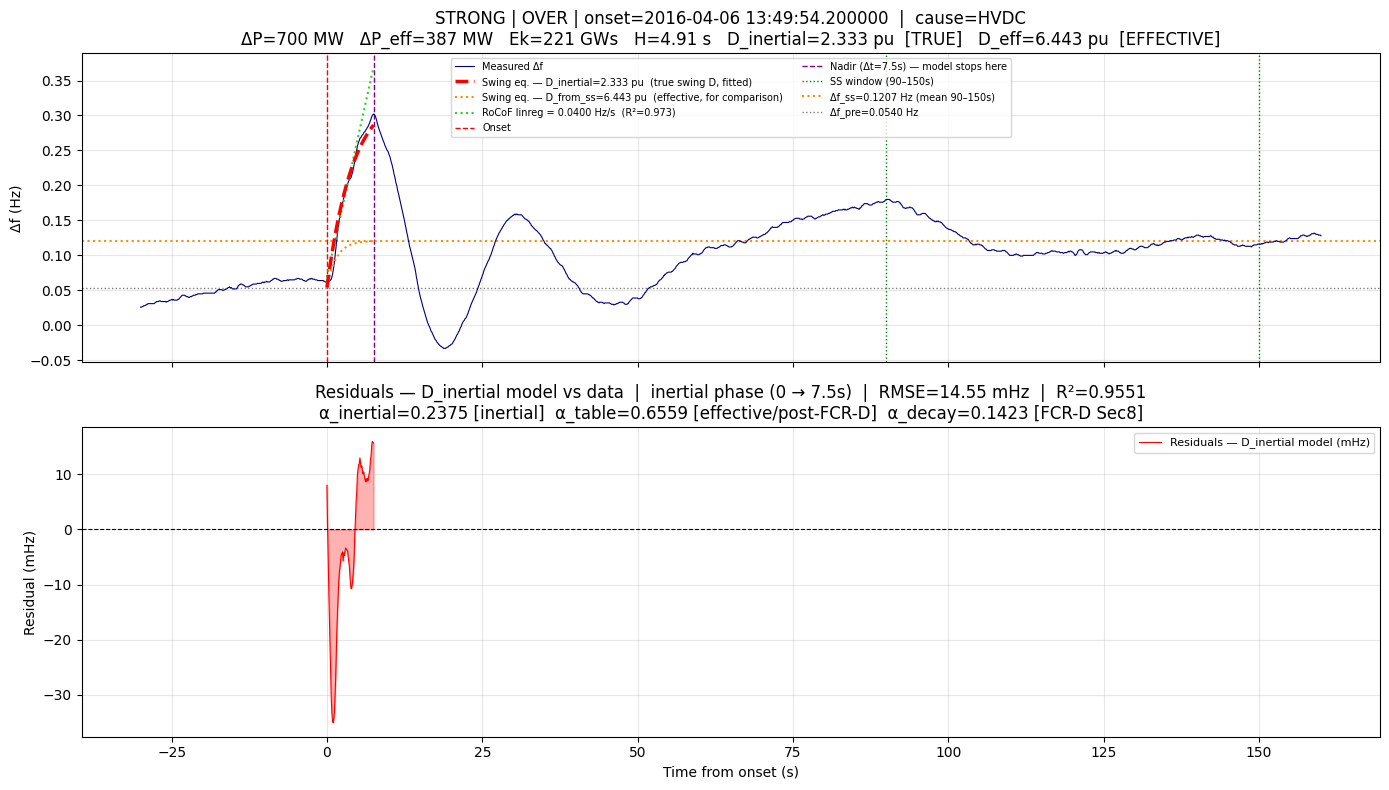

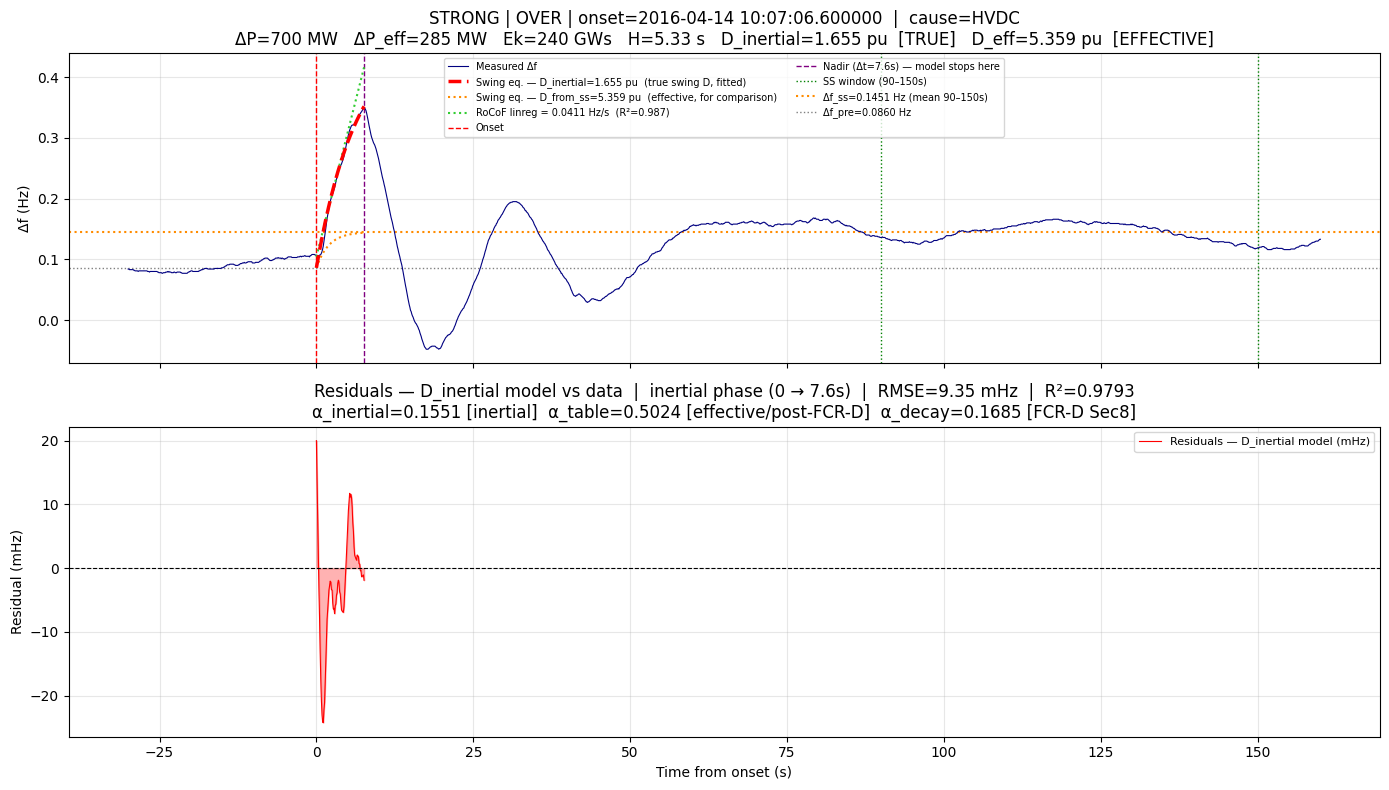

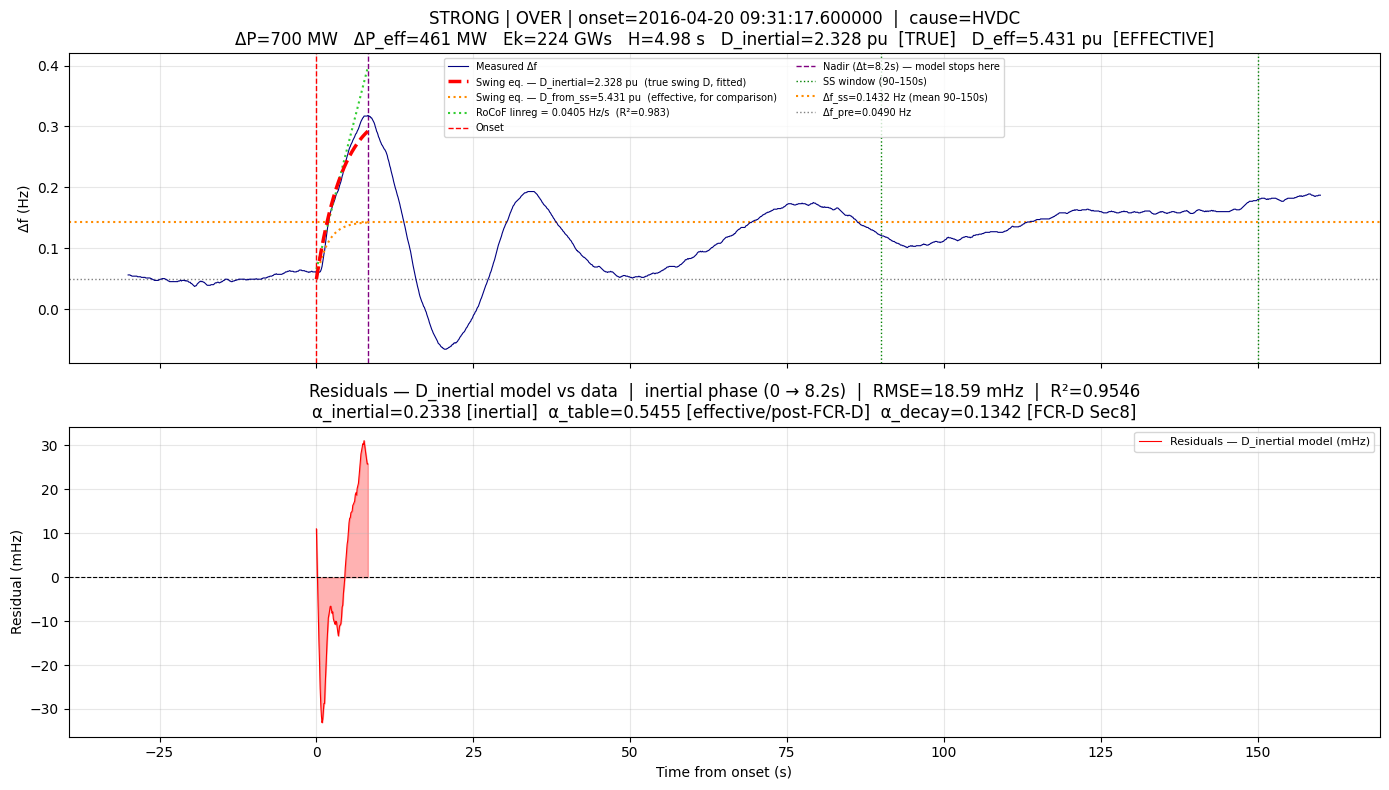

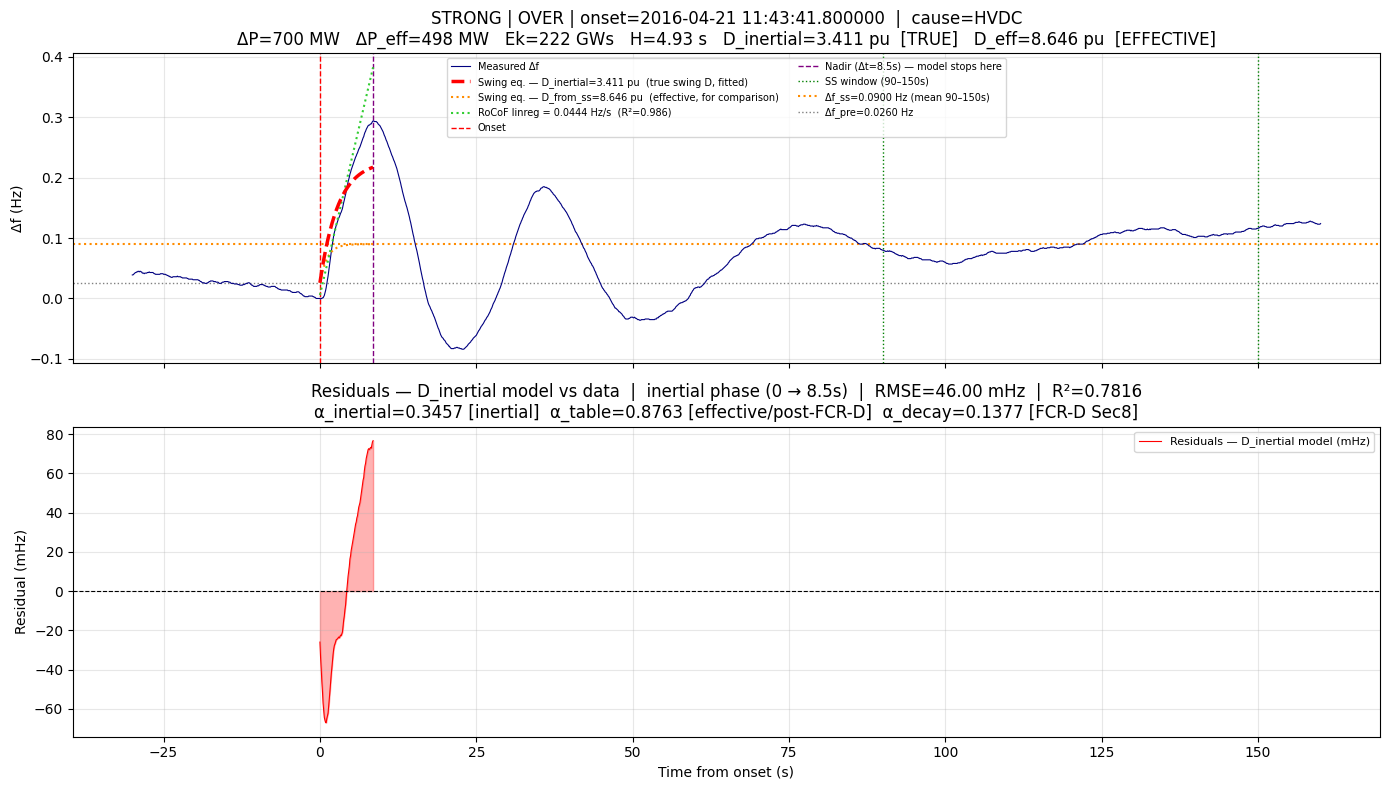

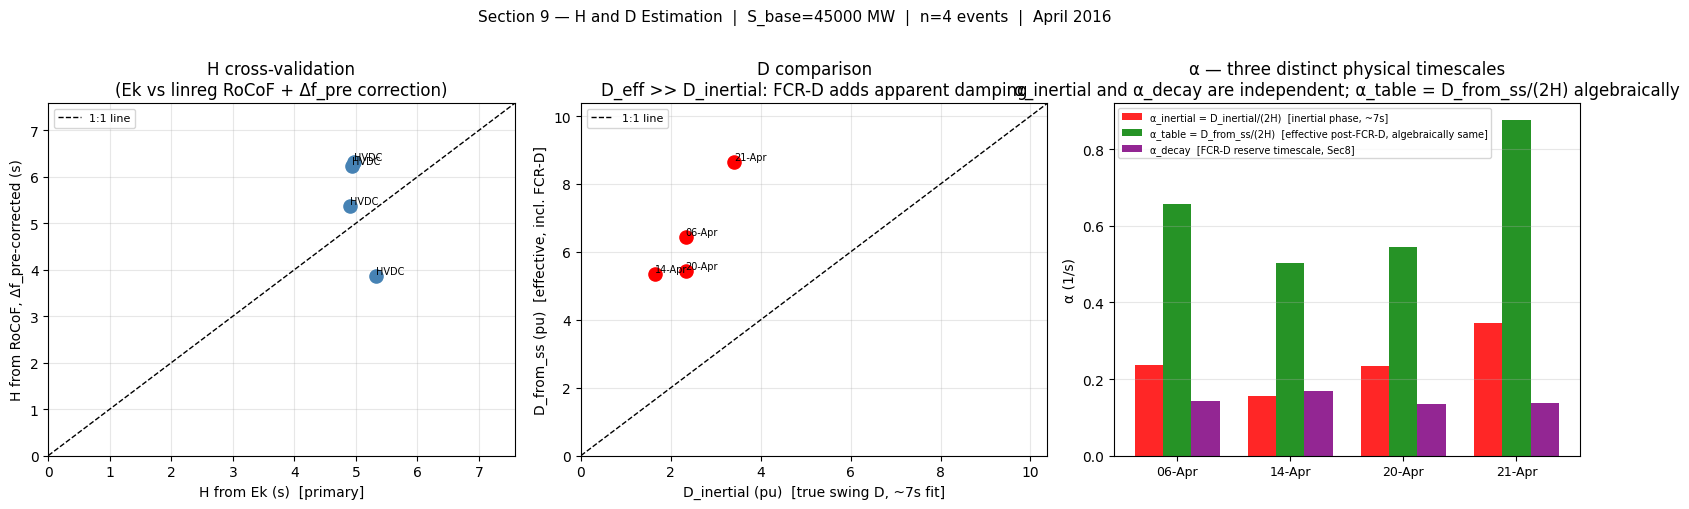


═════════════════════════════════════════════════════════════════
SECTION 9 COMPLETE
═════════════════════════════════════════════════════════════════
  Events processed           : 4
  H_est (from Ek) mean       : 5.039 s
  H (from RoCoF,corr) mean   : 5.444 s
  D_inertial mean  [TRUE]    : 2.4315 pu
  D_from_ss mean   [EFFECT.] : 6.4697 pu
  α_table mean  [effective]  : 0.64504 1/s  (= D_from_ss/2H, S_base cancels)
  α_inertial mean            : 0.24303 1/s  (independent, from D_inertial/2H)
  α_decay mean (Sec8/FCR-D)  : 0.14569 1/s
  D_inertial fit R² mean     : 0.9176
  RoCoF ratio corr mean      : 0.969
  S_base assumed             : 45000 MW
═════════════════════════════════════════════════════════════════


In [15]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 9 — H AND D ESTIMATION FROM SWING EQUATION WITH KNOWN ΔP AND Ek
#
# METHOD:
#   2H·dΔf/dt + D·Δf = ΔP_pu   (swing equation, all pu)
#
#   ΔP [MW] and Ek [GWs] known per event from TSO disturbance report.
#   H and D derived directly — no optimisation ambiguity, identifiability resolved.
#
#   H:
#     H_from_Ek    = Ek_GWs × 1000 / S_base_MW                     [primary]
#     H_from_RoCoF = (ΔP_pu - D·Δf_pre_pu) / (2 × |RoCoF_0_pu|)   [cross-check]
#     RoCoF_0 from linear regression over onset→nadir (mean inertial slope).
#
#   D — two physically distinct quantities:
#
#     D_from_ss [effective damping]:
#       D = ΔP_pu / |Δf_ss_pu|   where Δf_ss = mean(Δf) over 90–150s
#       Represents combined effect of load damping + FCR-D reserve response.
#       Useful for steady-state frequency deviation analysis.
#       NOT the pure swing equation D — FCR-D has already acted by 90s.
#
#     D_inertial [true swing equation D]:
#       Single-parameter fit of swing equation to onset→nadir data,
#       with H fixed from Ek and ΔP fixed from report table.
#       Only D is free → well-posed, identifiable single-parameter problem.
#       Reflects pure load damping during the ~7s inertial phase
#       before FCR-D has meaningfully activated.
#
#   α values — three physically distinct timescales:
#     α_table    = ΔP·f0 / (2·Ek·1000·|Δf_ss|)   [S_base-free, effective post-FCR-D α]
#       NOTE: α_table = D_from_ss/(2·H_Ek) algebraically (S_base cancels).
#             They are the SAME quantity computed two ways — not an independent check.
#             α_table uses Δf_ss (post-FCR-D quasi-steady state), so it reflects
#             combined load damping + FCR-D reserve response, NOT pure inertial damping.
#     α_inertial = D_inertial / (2·H_Ek)          [true inertial phase decay rate]
#       Genuinely independent: D_inertial comes from curve fit to onset→nadir data,
#       completely decoupled from Δf_ss. Reflects pure load damping before FCR-D acts.
#     α_decay    = Section 8 exponential fit to post-nadir recovery window
#       FCR-D reserve activation timescale. NOT a swing equation quantity.
#
# ═══════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.optimize import minimize_scalar

# ── Constants ─────────────────────────────────────────────────────────────────
S_BASE_MW   = 45000.0  # MW — Nordic synchronous load, April 2016 (stated assumption)
F0          = 50.0     # Hz
PRE_ONSET_S = 30.0     # s — pre-onset window for Δf_pre
SS_WIN_LO_S = 90.0     # s — steady-state window start (ENTSO-E convention)
SS_WIN_HI_S = 150.0    # s — steady-state window end

# D_inertial fit bounds [pu] — physically plausible load damping range
D_INERTIAL_LO = 0.05
D_INERTIAL_HI = 5.0

print("═" * 65)
print("SECTION 9 — H AND D ESTIMATION WITH KNOWN ΔP AND Ek")
print("═" * 65)
print(f"S_base (stated assumption) : {S_BASE_MW:.0f} MW")
print(f"f0                         : {F0:.1f} Hz")
print(f"RoCoF_0 method             : linear regression over onset→nadir")
print(f"D_from_ss                  : effective damping (ΔP/Δf_ss, 90–150s)")
print(f"D_inertial                 : true swing D — single-param fit, H and ΔP fixed")


# ── Report disturbance table — 2016 ──────────────────────────────────────────
report_events = pd.DataFrame([
    {"date_str": "2016-01-12 10:22:53", "delta_f_Hz": -0.335, "delta_P_MW": 1167, "delta_t_s":  9.0, "Ek_GWs": 274, "cause": "Nuclear"},
    {"date_str": "2016-02-09 22:05:28", "delta_f_Hz":  0.214, "delta_P_MW":  880, "delta_t_s":  8.3, "Ek_GWs": 252, "cause": "HVDC"},
    {"date_str": "2016-02-20 10:45:31", "delta_f_Hz": -0.348, "delta_P_MW": 1000, "delta_t_s": 10.7, "Ek_GWs": 227, "cause": "Nuclear"},
    {"date_str": "2016-02-24 12:30:29", "delta_f_Hz":  0.228, "delta_P_MW":  700, "delta_t_s":  9.0, "Ek_GWs": 251, "cause": "HVDC"},
    {"date_str": "2016-03-21 11:59:50", "delta_f_Hz":  0.269, "delta_P_MW":  723, "delta_t_s":  7.3, "Ek_GWs": 248, "cause": "HVDC"},
    {"date_str": "2016-04-06 13:49:55", "delta_f_Hz":  0.230, "delta_P_MW":  700, "delta_t_s":  6.7, "Ek_GWs": 221, "cause": "HVDC"},
    {"date_str": "2016-04-14 10:07:07", "delta_f_Hz":  0.234, "delta_P_MW":  700, "delta_t_s":  6.7, "Ek_GWs": 240, "cause": "HVDC"},
    {"date_str": "2016-04-20 09:31:18", "delta_f_Hz":  0.249, "delta_P_MW":  700, "delta_t_s":  7.1, "Ek_GWs": 224, "cause": "HVDC"},
    {"date_str": "2016-04-21 11:43:42", "delta_f_Hz":  0.283, "delta_P_MW":  700, "delta_t_s":  7.9, "Ek_GWs": 222, "cause": "HVDC"},
])
report_events['report_time'] = pd.to_datetime(report_events['date_str'])
report_events['direction']   = report_events['delta_f_Hz'].apply(
    lambda x: 'over' if x > 0 else 'under')


# ── Cross-match: report event → detected segment ──────────────────────────────
MATCH_TOL_S = 120

def match_report_to_segment(rrow, segs, tol=MATCH_TOL_S):
    r_time = rrow['report_time']
    t_lo   = r_time - pd.Timedelta(seconds=rrow['delta_t_s'] + tol)
    t_hi   = r_time + pd.Timedelta(seconds=30)
    cands  = segs[
        (segs['onset_time'] >= t_lo) &
        (segs['onset_time'] <= t_hi) &
        (segs['direction']  == rrow['direction'])
    ].copy()
    if cands.empty:
        return None, None
    expected    = r_time - pd.Timedelta(seconds=rrow['delta_t_s'])
    cands['dt'] = (cands['onset_time'] - expected).abs()
    best        = cands.nsmallest(1, 'dt')
    return best.index[0], best.iloc[0]

print("\n" + "─" * 65)
print("CROSS-MATCHING REPORT EVENTS → DETECTED SEGMENTS")
print("─" * 65)

matched_rows = []
for _, rrow in report_events.iterrows():
    seg_idx, seg = match_report_to_segment(rrow, segments_est)
    print(f"  {rrow['date_str']}  "
          f"{'✓ MATCHED' if seg_idx is not None else '✗ NO MATCH':12s}"
          f"  onset={str(seg['onset_time']) if seg_idx is not None else '—'}")
    if seg_idx is not None:
        matched_rows.append({**rrow.to_dict(),
                              'seg_idx'       : seg_idx,
                              'onset_time'    : seg['onset_time'],
                              'peak_df_Hz'    : seg['peak_df_Hz'],
                              'max_rocof_Hz_s': seg['max_rocof_Hz_s'],
                              'classification': seg['classification'],
                              'recovery_type' : seg['recovery_type'],
                              'peak_time'     : seg['peak_time']})

matched_df = pd.DataFrame(matched_rows)
print(f"\nMatched: {len(matched_df)} / {len(report_events)}")


# ── Swing equation analytical solution ───────────────────────────────────────
def swing_solution(t, H, D, dP_pu, df_pre_pu):
    """
    Δf_pu(t) = Δf_ss + (Δf_pre - Δf_ss) · exp(-αt)
    α = D/(2H),  Δf_ss = dP_pu/D
    Valid during inertial phase (constant ΔP, before FCR-D acts).
    """
    alpha  = D / (2.0 * H)
    df_ss  = dP_pu / D
    return df_ss + (df_pre_pu - df_ss) * np.exp(-alpha * t)


# ═══════════════════════════════════════════════════════════════════════════════
# MAIN ESTIMATION LOOP
# ═══════════════════════════════════════════════════════════════════════════════
results = []

print("\n" + "═" * 65)
print("H AND D ESTIMATION — PER EVENT")
print("═" * 65)

for _, mrow in matched_df.iterrows():
    seg_idx   = mrow['seg_idx']
    seg       = segments_est.loc[seg_idx]
    onset     = seg['onset_time']
    nadir_t   = mrow['peak_time']
    sign      = 1 if mrow['direction'] == 'over' else -1

    dP_MW  = mrow['delta_P_MW']
    Ek_GWs = mrow['Ek_GWs']
    dP_pu  = dP_MW / S_BASE_MW

    # ── Data windows ──────────────────────────────────────────────────────
    pre_win      = df_reliable.loc[
        onset - pd.Timedelta(seconds=PRE_ONSET_S) : onset]
    ss_win       = df_reliable.loc[
        onset + pd.Timedelta(seconds=SS_WIN_LO_S) :
        onset + pd.Timedelta(seconds=SS_WIN_HI_S)]
    #inertial_win = df_reliable.loc[onset : nadir_t]
    inertial_win = df_reliable.loc[onset : onset + pd.Timedelta(seconds=6)]
#
#
#
#
#
#
#
#could  change inertial wil time from onset to 2s instead of nadir_t to have a more precise inertial window
#
#
#
#
#
#
#


    if len(pre_win) < 5 or len(ss_win) < 5 or len(inertial_win) < 5:
        print(f"\n  Event {seg_idx}: insufficient data — skip")
        continue

    # ── Δf_pre ────────────────────────────────────────────────────────────
    df_pre_Hz = float(pre_win['delta_f_Hz'].median())
    df_pre_pu = df_pre_Hz / F0

    # ── Δf_ss: mean of 90–150s window ────────────────────────────────────
    df_ss_Hz  = float(ss_win['delta_f_Hz'].mean())
    df_ss_pu  = df_ss_Hz / F0

    # ── RoCoF_0: linear regression over inertial phase ───────────────────
    t_vals  = (inertial_win.index - onset).total_seconds().values
    df_vals = inertial_win['delta_f_Hz'].values
    rocof_slope, rocof_intercept, rocof_r, *_ = linregress(t_vals, df_vals)
    rocof_0_Hz_s = rocof_slope
    rocof_0_pu_s = rocof_0_Hz_s / F0

    # ── H estimates ───────────────────────────────────────────────────────
    H_from_Ek = Ek_GWs * 1000.0 / S_BASE_MW   # primary

    # ── D_from_ss: effective damping (post-FCR-D steady state) ───────────
    D_from_ss = (dP_pu / abs(df_ss_pu) if abs(df_ss_pu) > 1e-4 else np.nan)

    # ── H_from_RoCoF: cross-check with Δf_pre correction ─────────────────
    # At t=0+: 2H·RoCoF_0 = ΔP_pu - D·Δf_pre_pu  (exact, no approximation)
    # Use D_from_ss for the correction term (best available D estimate at this point)
    if abs(rocof_0_pu_s) > 1e-6 and not np.isnan(D_from_ss):
        dP_eff_pu    = dP_pu - D_from_ss * abs(df_pre_pu)
        H_from_rocof = dP_eff_pu / (2.0 * abs(rocof_0_pu_s))
    else:
        dP_eff_pu    = np.nan
        H_from_rocof = np.nan

    H_est = H_from_Ek   # primary throughout

    # ── D_inertial: single-parameter fit, H and ΔP fixed ─────────────────
    # Fits swing equation to onset→nadir Δf_pu data.
    # Only D is free — H=H_from_Ek, ΔP=from table.
    # Well-posed: one equation, one unknown at each time step.
    t_fit    = t_vals.copy()
    df_fit_pu = df_vals / F0   # convert to pu for swing equation

    dP_signed_pu = dP_pu * sign

    def cost_D(D_try):
        if D_try <= 0:
            return 1e12
        df_pred = swing_solution(t_fit, H_est, D_try, dP_signed_pu, df_pre_pu)
        return np.sum((df_fit_pu - df_pred) ** 2)

    opt = minimize_scalar(cost_D,
                          bounds=(D_INERTIAL_LO, D_INERTIAL_HI),
                          method='bounded',
                          options={'xatol': 1e-8})
    D_inertial = opt.x if opt.success else np.nan

    # R² of the inertial fit
    if not np.isnan(D_inertial):
        df_pred_pu  = swing_solution(t_fit, H_est, D_inertial,
                                     dP_signed_pu, df_pre_pu)
        ss_res      = np.sum((df_fit_pu - df_pred_pu)**2)
        ss_tot      = np.sum((df_fit_pu - df_fit_pu.mean())**2)
        r2_inertial = 1.0 - ss_res/ss_tot if ss_tot > 1e-12 else np.nan
        rmse_inertial_mHz = np.sqrt(np.mean(((df_fit_pu - df_pred_pu)*F0*1000)**2))
    else:
        r2_inertial = np.nan
        rmse_inertial_mHz = np.nan

    # ── α values ─────────────────────────────────────────────────────────
    # α_table: S_base-free expression of effective post-FCR-D decay rate.
    # Algebraically identical to D_from_ss/(2·H_Ek) — S_base cancels exactly.
    # Reporting both would be a tautology; α_table is the canonical S_base-free form.
    alpha_table    = (dP_MW * F0 / (2.0 * Ek_GWs * 1000.0 * abs(df_ss_Hz))
                      if abs(df_ss_Hz) > 1e-4 else np.nan)
    # α_inertial: genuinely independent — from D_inertial curve fit, not from Δf_ss
    alpha_inertial = D_inertial / (2.0 * H_est) if not np.isnan(D_inertial) else np.nan

    # Section 8 decay α (FCR-D timescale, for reference only)
    decay_row   = decay_good[decay_good['segment_idx'] == seg_idx]
    alpha_decay = float(decay_row['alpha'].iloc[0]) if not decay_row.empty else np.nan

    # ── RoCoF validation ──────────────────────────────────────────────────
    rocof_pred_raw = dP_MW * F0 / (2.0 * Ek_GWs * 1000.0)
    dP_eff_MW      = (dP_eff_pu * S_BASE_MW if not np.isnan(dP_eff_pu) else np.nan)
    rocof_pred_eff = (dP_eff_MW * F0 / (2.0 * Ek_GWs * 1000.0)
                      if not np.isnan(dP_eff_MW) else np.nan)
    rocof_ratio_raw = abs(rocof_0_Hz_s) / rocof_pred_raw
    rocof_ratio_eff = (abs(rocof_0_Hz_s) / rocof_pred_eff
                       if (rocof_pred_eff is not None and
                           not np.isnan(rocof_pred_eff) and
                           rocof_pred_eff > 0) else np.nan)

    t_nadir_s = (nadir_t - onset).total_seconds()

    print(f"\n{'─'*65}")
    print(f"Event {seg_idx} | {mrow['classification']} | "
          f"{mrow['direction'].upper()} | cause={mrow['cause']}")
    print(f"  onset={onset}   nadir Δt={t_nadir_s:.1f}s")
    print(f"  [TABLE] ΔP={dP_MW:.0f} MW  Ek={Ek_GWs:.0f} GWs  "
          f"Δf_nadir={mrow['delta_f_Hz']:.3f} Hz")
    print(f"  [DATA]  Δf_pre={df_pre_Hz:.4f} Hz  Δf_ss={df_ss_Hz:.4f} Hz  "
          f"RoCoF_0={rocof_0_Hz_s:.5f} Hz/s  (linreg R²={rocof_r**2:.3f})")
    print(f"  ── H ──────────────────────────────────────────────────")
    print(f"    H_from_Ek         = {H_from_Ek:.3f} s   [primary]")
    print(f"    H_from_RoCoF      = {H_from_rocof:.3f} s   [cross-check, Δf_pre-corrected]")
    print(f"    Ratio H_RoCoF/H_Ek = {H_from_rocof/H_from_Ek:.3f}")
    print(f"  ── D ──────────────────────────────────────────────────")
    print(f"    D_from_ss         = {D_from_ss:.4f} pu  [effective: load damping + FCR-D]")
    print(f"    D_inertial        = {D_inertial:.4f} pu  [true swing D: inertial phase fit]")
    print(f"    D_inertial fit R² = {r2_inertial:.4f}  RMSE={rmse_inertial_mHz:.2f} mHz")
    print(f"  ── α (three distinct physical timescales) ─────────────")
    print(f"    α_table    = {alpha_table:.5f} 1/s  [effective post-FCR-D]")
    print(f"      = D_from_ss/(2H) = ΔP·f0/(2·Ek·|Δf_ss|)  — same quantity, S_base cancels")
    print(f"    α_inertial = {alpha_inertial:.5f} 1/s  [inertial phase only, independent of Δf_ss]")
    print(f"      = D_inertial/(2H), D_inertial from curve fit to onset→nadir data")
    print(f"    α_decay    = {alpha_decay:.5f} 1/s  [FCR-D reserve timescale, Sec8 post-nadir fit]")
    print(f"  ── RoCoF validation (S_base-free) ─────────────────────")
    print(f"    RoCoF_pred raw    = {rocof_pred_raw:.5f} Hz/s  (ΔP·f0/2Ek, no Δf_pre)")
    print(f"    RoCoF_pred eff    = {rocof_pred_eff:.5f} Hz/s  (Δf_pre-corrected)")
    print(f"    RoCoF measured    = {abs(rocof_0_Hz_s):.5f} Hz/s  (linreg)")
    print(f"    Ratio raw         = {rocof_ratio_raw:.3f}")
    print(f"    Ratio corrected   = {rocof_ratio_eff:.3f}")

    results.append({
        'seg_idx'          : seg_idx,
        'onset_time'       : onset,
        'nadir_time'       : nadir_t,
        't_nadir_s'        : t_nadir_s,
        'direction'        : mrow['direction'],
        'classification'   : mrow['classification'],
        'cause'            : mrow['cause'],
        'dP_MW'            : dP_MW,
        'Ek_GWs'           : Ek_GWs,
        'dP_pu'            : dP_pu,
        'dP_eff_MW'        : dP_eff_MW,
        'df_nadir_Hz'      : mrow['delta_f_Hz'],
        'df_ss_Hz'         : df_ss_Hz,
        'df_pre_Hz'        : df_pre_Hz,
        'df_pre_pu'        : df_pre_pu,
        'rocof_0_Hz_s'     : rocof_0_Hz_s,
        'rocof_r2'         : rocof_r**2,
        'rocof_pred_raw'   : rocof_pred_raw,
        'rocof_pred_eff'   : rocof_pred_eff,
        'rocof_ratio_raw'  : rocof_ratio_raw,
        'rocof_ratio_eff'  : rocof_ratio_eff,
        'alpha_decay'      : alpha_decay,
        'alpha_table'      : alpha_table,
        'alpha_inertial'   : alpha_inertial,
        'H_from_Ek'        : H_from_Ek,
        'H_from_rocof'     : H_from_rocof,
        'H_est'            : H_from_Ek,
        'D_from_ss'        : D_from_ss,
        'D_inertial'       : D_inertial,
        'D_est'            : D_inertial,      # true swing D is primary for model
        'r2_inertial'      : r2_inertial,
        'rmse_inertial_mHz': rmse_inertial_mHz,
        'recovery_type'    : mrow['recovery_type'],
        'peak_df_Hz'       : mrow['peak_df_Hz'],
        'max_rocof_Hz_s'   : mrow['max_rocof_Hz_s'],
    })

results_df = pd.DataFrame(results)


# ═══════════════════════════════════════════════════════════════════════════════
# SUMMARY TABLE
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "═" * 65)
print("SECTION 9 — RESULTS SUMMARY")
print("═" * 65)
print(f"S_base={S_BASE_MW:.0f} MW | H from Ek | D_inertial from single-param fit\n")

for label, col in [
    ("H_est (from Ek) [s]",        "H_from_Ek"),
    ("H (from RoCoF, corr.) [s]",  "H_from_rocof"),
    ("D_inertial [pu]  ← TRUE D",  "D_inertial"),
    ("D_from_ss [pu]   ← EFFECTIVE","D_from_ss"),
    ("α_table [1/s]  (= D_ss/2H)", "alpha_table"),
    ("α_inertial [1/s]  (D_in/2H)","alpha_inertial"),
    ("α_decay (Sec8) [1/s]",       "alpha_decay"),
    ("D_inertial fit R²",          "r2_inertial"),
    ("D_inertial RMSE [mHz]",      "rmse_inertial_mHz"),
    ("RoCoF ratio (raw)",          "rocof_ratio_raw"),
    ("RoCoF ratio (Δf_pre corr.)", "rocof_ratio_eff"),
]:
    s = results_df[col].dropna()
    print(f"  {label:<32}: mean={s.mean():.4f}  std={s.std():.4f}  "
          f"[{s.min():.4f}, {s.max():.4f}]")

print(f"""
  Interpretation:
    H         = {results_df['H_from_Ek'].mean():.2f} s  — inertia constant (from Ek, literature-consistent)
    D_inertial= {results_df['D_inertial'].mean():.3f} pu — load damping during inertial phase (~7s)
    D_from_ss = {results_df['D_from_ss'].mean():.3f} pu — effective system damping incl. FCR-D (90–150s)
    D_from_ss >> D_inertial: FCR-D reserves act as additional apparent damping
    in the post-nadir steady state — absorbed into D_from_ss but not present
    during the true inertial phase captured by D_inertial.
""")


# ═══════════════════════════════════════════════════════════════════════════════
# PER-EVENT DIAGNOSTIC PLOTS
# ═══════════════════════════════════════════════════════════════════════════════
for _, row in results_df.iterrows():
    seg_idx   = row['seg_idx']
    seg       = segments_est.loc[seg_idx]
    onset     = seg['onset_time']
    nadir_t   = row['nadir_time']
    t_nadir_s = row['t_nadir_s']
    sign      = 1 if row['direction'] == 'over' else -1

    # Full measurement window
    plot_start = onset - pd.Timedelta(seconds=30)
    plot_end   = onset + pd.Timedelta(seconds=160)
    window     = df_reliable.loc[plot_start:plot_end]
    t_plot     = (window.index - onset).total_seconds().values
    df_plot_Hz = window['delta_f_Hz'].values

    H_e      = row['H_est']
    dP_p     = row['dP_pu'] * sign
    df_pre_pu = row['df_pre_pu']
    t_model   = np.linspace(0, t_nadir_s, 500)

    # Model curve using D_inertial (true swing D)
    D_inert = row['D_inertial']
    model_inertial_ok = not (np.isnan(H_e) or np.isnan(D_inert) or
                              D_inert <= 0 or H_e <= 0)
    if model_inertial_ok:
        df_model_inertial_Hz = swing_solution(
            t_model, H_e, D_inert, dP_p, df_pre_pu) * F0

    # Model curve using D_from_ss (effective D) — for comparison
    D_ss = row['D_from_ss']
    model_ss_ok = not (np.isnan(H_e) or np.isnan(D_ss) or D_ss <= 0)
    if model_ss_ok:
        df_model_ss_Hz = swing_solution(
            t_model, H_e, D_ss, dP_p, df_pre_pu) * F0

    # Linear regression line (RoCoF visual)
    inertial_win = df_reliable.loc[onset : nadir_t]
    t_reg  = (inertial_win.index - onset).total_seconds().values
    df_reg = inertial_win['delta_f_Hz'].values
    _, intercept_reg, *_ = linregress(t_reg, df_reg)
    t_reg_line  = np.array([0, t_nadir_s])
    df_reg_line = row['rocof_0_Hz_s'] * t_reg_line + intercept_reg

    # Residuals: D_inertial model vs data
    if model_inertial_ok and len(t_reg) > 0:
        df_res_model  = np.interp(t_reg, t_model, df_model_inertial_Hz)
        residuals_mHz = (df_reg - df_res_model) * 1000.0
        rmse_val      = np.sqrt(np.mean(residuals_mHz**2))
    else:
        residuals_mHz = np.zeros_like(t_reg)
        rmse_val      = np.nan

    # ── Figure ────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # Panel 1: Δf
    axes[0].plot(t_plot, df_plot_Hz, color='navy', linewidth=0.8,
                 label='Measured Δf', zorder=3)

    if model_inertial_ok:
        axes[0].plot(t_model, df_model_inertial_Hz,
                     color='red', linewidth=2.5, linestyle='--', zorder=5,
                     label=f'Swing eq. — D_inertial={D_inert:.3f} pu  '
                           f'(true swing D, fitted)')
    if model_ss_ok:
        axes[0].plot(t_model, df_model_ss_Hz,
                     color='darkorange', linewidth=1.5, linestyle=':', zorder=4,
                     label=f'Swing eq. — D_from_ss={D_ss:.3f} pu  '
                           f'(effective, for comparison)')

    axes[0].plot(t_reg_line, df_reg_line,
                 color='limegreen', linewidth=1.5, linestyle=':', zorder=4,
                 label=f'RoCoF linreg = {row["rocof_0_Hz_s"]:.4f} Hz/s  '
                       f'(R²={row["rocof_r2"]:.3f})')

    axes[0].axvline(0,           color='red',    linestyle='--', linewidth=1.0,
                    label='Onset')
    axes[0].axvline(t_nadir_s,   color='purple', linestyle='--', linewidth=1.0,
                    label=f'Nadir (Δt={t_nadir_s:.1f}s) — model stops here')
    axes[0].axvline(SS_WIN_LO_S, color='green',  linestyle=':',  linewidth=1.0)
    axes[0].axvline(SS_WIN_HI_S, color='green',  linestyle=':',  linewidth=1.0,
                    label='SS window (90–150s)')
    axes[0].axhline(row['df_ss_Hz'], color='darkorange', linestyle=':',
                    linewidth=1.5,
                    label=f'Δf_ss={row["df_ss_Hz"]:.4f} Hz (mean 90–150s)')
    axes[0].axhline(row['df_pre_Hz'], color='gray', linestyle=':',
                    linewidth=1.0,
                    label=f'Δf_pre={row["df_pre_Hz"]:.4f} Hz')

    axes[0].set_ylabel('Δf (Hz)')
    axes[0].set_title(
        f"{row['classification']} | {row['direction'].upper()} | "
        f"onset={row['onset_time']}  |  cause={row['cause']}\n"
        f"ΔP={row['dP_MW']:.0f} MW   ΔP_eff={row['dP_eff_MW']:.0f} MW   "
        f"Ek={row['Ek_GWs']:.0f} GWs   "
        f"H={row['H_from_Ek']:.2f} s   "
        f"D_inertial={row['D_inertial']:.3f} pu  [TRUE]   "
        f"D_eff={row['D_from_ss']:.3f} pu  [EFFECTIVE]"
    )
    axes[0].legend(fontsize=7, ncol=2)
    axes[0].grid(True, alpha=0.3)

    # Panel 2: residuals (D_inertial model)
    axes[1].plot(t_reg, residuals_mHz, color='red', linewidth=0.8,
                 label='Residuals — D_inertial model (mHz)')
    axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[1].fill_between(t_reg, residuals_mHz, 0, alpha=0.3, color='red')
    axes[1].set_ylabel('Residual (mHz)')
    axes[1].set_xlabel('Time from onset (s)')
    axes[1].set_title(
        f"Residuals — D_inertial model vs data  |  "
        f"inertial phase (0 → {t_nadir_s:.1f}s)  |  "
        f"RMSE={rmse_val:.2f} mHz  |  R²={row['r2_inertial']:.4f}\n"
        f"α_inertial={row['alpha_inertial']:.4f} [inertial]  "
        f"α_table={row['alpha_table']:.4f} [effective/post-FCR-D]  "
        f"α_decay={row['alpha_decay']:.4f} [FCR-D Sec8]"
    )
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# SUMMARY PLOTS
# ═══════════════════════════════════════════════════════════════════════════════
if len(results_df) >= 2:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Plot 1: H cross-validation
    x, y = results_df['H_from_Ek'], results_df['H_from_rocof']
    axes[0].scatter(x, y, c='steelblue', s=90, zorder=3)
    lim = [0, max(x.max(), y.max()) * 1.2]
    axes[0].plot(lim, lim, 'k--', linewidth=1, label='1:1 line')
    for _, r in results_df.iterrows():
        axes[0].annotate(r['cause'], (r['H_from_Ek'], r['H_from_rocof']),
                         fontsize=7, ha='left', va='bottom')
    axes[0].set_xlim(lim); axes[0].set_ylim(lim)
    axes[0].set_xlabel('H from Ek (s)  [primary]')
    axes[0].set_ylabel('H from RoCoF, Δf_pre-corrected (s)')
    axes[0].set_title('H cross-validation\n(Ek vs linreg RoCoF + Δf_pre correction)')
    axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

    # Plot 2: D comparison — inertial vs effective
    axes[1].scatter(results_df['D_inertial'], results_df['D_from_ss'],
                    c='red', s=90, zorder=3)
    lim2 = [0, results_df['D_from_ss'].max() * 1.2]
    axes[1].plot(lim2, lim2, 'k--', linewidth=1, label='1:1 line')
    for _, r in results_df.iterrows():
        axes[1].annotate(
            f"{r['onset_time'].strftime('%d-%b')}",
            (r['D_inertial'], r['D_from_ss']),
            fontsize=7, ha='left', va='bottom')
    axes[1].set_xlim([0, lim2[1]]); axes[1].set_ylim([0, lim2[1]])
    axes[1].set_xlabel('D_inertial (pu)  [true swing D, ~7s fit]')
    axes[1].set_ylabel('D_from_ss (pu)  [effective, incl. FCR-D]')
    axes[1].set_title('D comparison\nD_eff >> D_inertial: FCR-D adds apparent damping')
    axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

    # Plot 3: α comparison — three distinct physical timescales
    x_ev   = np.arange(len(results_df))
    width  = 0.25
    labels = [f"{pd.Timestamp(r['onset_time']).strftime('%d-%b')}"
              for _, r in results_df.iterrows()]
    axes[2].bar(x_ev - width, results_df['alpha_inertial'],
                width, color='red',    alpha=0.85,
                label='α_inertial = D_inertial/(2H)  [inertial phase, ~7s]')
    axes[2].bar(x_ev,          results_df['alpha_table'],
                width, color='green',  alpha=0.85,
                label='α_table = D_from_ss/(2H)  [effective post-FCR-D, algebraically same]')
    axes[2].bar(x_ev + width,  results_df['alpha_decay'],
                width, color='purple', alpha=0.85,
                label='α_decay  [FCR-D reserve timescale, Sec8]')
    axes[2].set_xticks(x_ev); axes[2].set_xticklabels(labels, fontsize=9)
    axes[2].set_ylabel('α (1/s)')
    axes[2].set_title(
        'α — three distinct physical timescales\n'
        'α_inertial and α_decay are independent; α_table = D_from_ss/(2H) algebraically'
    )
    axes[2].legend(fontsize=7); axes[2].grid(True, alpha=0.3, axis='y')

    plt.suptitle(
        f'Section 9 — H and D Estimation  |  S_base={S_BASE_MW:.0f} MW  |  '
        f'n={len(results_df)} events  |  April 2016',
        fontsize=11, y=1.01
    )
    plt.tight_layout()
    plt.show()


# ── Final summary ─────────────────────────────────────────────────────────────
print("\n" + "═" * 65)
print("SECTION 9 COMPLETE")
print("═" * 65)
print(f"  Events processed           : {len(results_df)}")
print(f"  H_est (from Ek) mean       : {results_df['H_from_Ek'].mean():.3f} s")
print(f"  H (from RoCoF,corr) mean   : {results_df['H_from_rocof'].mean():.3f} s")
print(f"  D_inertial mean  [TRUE]    : {results_df['D_inertial'].mean():.4f} pu")
print(f"  D_from_ss mean   [EFFECT.] : {results_df['D_from_ss'].mean():.4f} pu")
print(f"  α_table mean  [effective]  : {results_df['alpha_table'].mean():.5f} 1/s  (= D_from_ss/2H, S_base cancels)")
print(f"  α_inertial mean            : {results_df['alpha_inertial'].mean():.5f} 1/s  (independent, from D_inertial/2H)")
print(f"  α_decay mean (Sec8/FCR-D)  : {results_df['alpha_decay'].mean():.5f} 1/s")
print(f"  D_inertial fit R² mean     : {results_df['r2_inertial'].mean():.4f}")
print(f"  RoCoF ratio corr mean      : {results_df['rocof_ratio_eff'].mean():.3f}")
print(f"  S_base assumed             : {S_BASE_MW:.0f} MW")
print("═" * 65)